<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Descargar el archivo worldbank_dataset.csv (commiteado en el repo, sin depender de Google Drive)
!wget -q -O worldbank_dataset.csv https://raw.githubusercontent.com/AlesioRios/Laboratorio-de-Datos-II/main/data/worldbank_dataset.csv

In [ ]:
import pandas as pd

df = pd.read_csv('/content/worldbank_dataset.csv')

# Ejercicio 1

## 1.1 Análisis exploratorio inicial

EDA de diagnóstico antes de cualquier tratamiento de faltantes, transformación o estandarización (eso es Ejercicio 1, puntos 2 a 4, y queda para después). El objetivo acá es entender qué hay: nulos, rango/orden de magnitud de cada variable, y forma de las distribuciones.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from IPython.display import display, HTML


def estilizar(df, cmap='Blues', precision=2):
  # Codifica una tabla con color en vez de imprimirla como texto plano (heatmap-style, por columna).
  # Ademas de background_gradient, se agregan estilos de tabla explicitos: al extraer el
  # HTML con .to_html() para mostrarlo dentro de un <div> propio (mostrar_lado_a_lado),
  # se pierde el CSS por default que Colab/Jupyter le pone a un DataFrame (padding, bordes,
  # tipografia) - sin esto se ve mas apretado/plano que una tabla mostrada normalmente.
  estilos_tabla = [
      {'selector': 'th', 'props': [('padding', '6px 12px'), ('text-align', 'center'), ('border', '1px solid #d0d7de'), ('background-color', '#f6f8fa')]},
      {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'center'), ('border', '1px solid #d0d7de')]},
      {'selector': ''  , 'props': [('border-collapse', 'collapse'), ('font-size', '13px')]},
  ]
  return (
      df.style
      .background_gradient(cmap=cmap, axis=0)
      .format(precision=precision)
      .set_table_styles(estilos_tabla)
  )


def mostrar_lado_a_lado(tablas, cmap='Blues', precision=2):
  # Muestra varias tablas en una fila horizontal (en vez de apiladas) para que entren juntas en pantalla.
  # Cada tabla queda dentro de una tarjeta con borde propio, con mas separacion entre ellas
  # y entre el titulo y la tabla, para que se vea prolijo en vez de amontonado.
  bloques = []
  for titulo, df in tablas:
    bloques.append(
        "<div style='margin:0 32px 20px 0; padding:12px 14px; "
        "border:1px solid #d0d7de; border-radius:10px;'>"
        f"<div style='font-weight:600; margin-bottom:8px;'>{titulo}</div>"
        f"{estilizar(df, cmap=cmap, precision=precision).to_html()}</div>"
    )
  display(HTML("<div style='display:flex; flex-wrap:wrap;'>" + ''.join(bloques) + "</div>"))


# Variable objetivo de todo el TP3 (problema de regresion)
TARGET = 'gdp_per_capita_current_us$'

# country/iso_code/countryiso3 son tres codificaciones del mismo pais (misma cardinalidad,
# 144 cada una) - se excluyen del analisis numerico para no analizar tres veces lo mismo.
COLUMNAS_ID = ['country', 'iso_code', 'countryiso3']
columnas_numericas = [c for c in df.columns if c not in COLUMNAS_ID and c != 'year']

### 1. Estructura del dataset

¿Con cuántos datos contamos y de qué tipo es cada columna?

In [ ]:
print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Paises: {df['country'].nunique()} | Anios: {df['year'].min()}-{df['year'].max()} (panel pais-anio)")

display(df.dtypes.value_counts().rename('Cantidad de columnas').to_frame())
df.head()

### Conclusiones — Estructura

- ¿Cuántas variables numéricas hay realmente para trabajar (descontando `country`/`iso_code`/`countryiso3`)?
- ¿El hecho de que sea un panel país-año (144 países × hasta 28 años) cambia algo de cómo pensás las filas del dataset?

<!-- Completar -->

### 2. Nulos por columna

¿Dónde falta información y cuánta? `iso_code`/`countryiso3` quedan afuera del análisis numérico por ser redundantes con `country` (misma cardinalidad, 144 países).

In [ ]:
resumen_nulos = pd.DataFrame({
    'Tipo de dato': df.dtypes.astype(str),
    'No nulos': df.notna().sum(),
    'Nulos': df.isna().sum(),
    '% nulos': (df.isna().sum() / len(df) * 100).round(2),
}).sort_values('% nulos', ascending=False)

# Se muestra sin estilizar (mismo criterio que TP2): mezcla texto + numeros, y lo
# que importa aca es poder ordenar/leer la tabla completa, no resaltarla con color.
display(resumen_nulos)

# Barra horizontal de % de nulos: mas legible que msno.matrix con 64 etiquetas en el eje.
datos_grafico = resumen_nulos[resumen_nulos['% nulos'] > 0].sort_values('% nulos')
fig, ax = plt.subplots(figsize=(8, 14))
ax.barh(datos_grafico.index, datos_grafico['% nulos'], color='#4C72B0')
ax.set_xlabel('% de nulos')
ax.set_title('Proporcion de valores faltantes por columna')
plt.tight_layout()
plt.show()

print(f"Columnas sin nulos: {(resumen_nulos['% nulos'] == 0).sum()} de {len(resumen_nulos)}")

In [ ]:
porc = 1
columnas_con_nulos = resumen_nulos[resumen_nulos['% nulos'] > porc].index.tolist()

df_ordenado_por_fecha = df.sort_values(['year','country']).reset_index(drop=True)
df_ordenado_por_pais = df.sort_values(['country', 'year']).reset_index(drop=True)

msno.matrix(df_ordenado_por_fecha[columnas_con_nulos], figsize=(14, 6), fontsize=8)
plt.title(f'Ubicacion de los nulos ordenados por year (columnas con >{porc}% de faltantes)')
plt.show()

msno.matrix(df_ordenado_por_pais[columnas_con_nulos], figsize=(14, 6), fontsize=8)
plt.title(f'Ubicacion de los nulos ordenados por country (columnas con >{porc}% de faltantes)')
plt.show()

msno.heatmap(df[columnas_con_nulos], figsize=(14, 12), fontsize=8)
plt.title('Correlacion de nulidad entre columnas')
plt.show()

### Conclusiones — Patrón de nulos

- `judicial_effectiveness` y `fiscal_health` tienen correlación de nulidad ≈1, igual que los dos `poverty_headcount_ratio` con `gini_index`. ¿Qué sugiere esto sobre el origen de esos faltantes (una misma encuesta/fuente que no cubre ciertos países-año)?
- ¿Este patrón es más compatible con MCAR (aleatorio) o con MAR/MNAR (asociado a qué tan desarrollado está el país o a qué tan buena es su infraestructura estadística)?

<!-- Completar -->

### Dendrograma entre features

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

variables_numericas = df.select_dtypes(include='number').columns.tolist()

def calcular_matriz_correlacion(df, columnas):
    """Correlacion pairwise-complete: cada par de columnas usa solo las filas
    donde ambas tienen dato, sin necesidad de imputar previamente."""
    return df[columnas].corr()

def graficar_dendrograma_correlacion(matriz_corr, titulo):
    # Convertimos correlacion en distancia: 1 - |corr|. Variables muy
    # correlacionadas (en valor absoluto) quedan cerca; da igual el signo,
    # porque para elegir predictor de imputacion nos interesa la fuerza del
    # vinculo, no la direccion.
    distancia = (1 - matriz_corr.abs()).to_numpy().copy()
    np.fill_diagonal(distancia, 0)
    distancia_condensada = squareform(distancia, checks=False)
    enlaces = linkage(distancia_condensada, method='average')

    fig, ax = plt.subplots(figsize=(14, 7))
    dendrogram(enlaces, labels=matriz_corr.columns.tolist(),
               leaf_rotation=90, leaf_font_size=9, ax=ax)
    ax.set_title(titulo)
    ax.set_ylabel('Distancia (1 - |correlacion|)')
    plt.tight_layout()
    plt.show()

matriz_corr_cruda = calcular_matriz_correlacion(df, variables_numericas)

graficar_dendrograma_correlacion(matriz_corr_cruda,
    'Dendrograma de correlacion entre features (datos crudos sin imputar)')

### 4. Rango y orden de magnitud de cada variable numérica

`describe()` transpuesto y coloreado por columna (cada estadístico se compara contra sí mismo a través de las variables) para que salte a la vista la diferencia de escalas.

In [ ]:
describe_numericas = df[columnas_numericas].describe().T
display(estilizar(describe_numericas, cmap='Blues', precision=2))

### 5. Correlación con el target

Con 60 variables numéricas no tiene sentido graficar la distribución de todas ("principales variables" de la consigna) — se usa la correlación de Pearson con el target como criterio objetivo de selección. De paso, esto anticipa el filtro univariado que el Ejercicio 3 va a aplicar formalmente (no se resuelve acá).

In [ ]:
correlacion_target = df[columnas_numericas].corr(numeric_only=True)[TARGET].drop(TARGET)
correlacion_target = correlacion_target.reindex(correlacion_target.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 14))
colores = ['#4C72B0' if v > 0 else '#C44E52' for v in correlacion_target.values]
ax.barh(correlacion_target.index[::-1], correlacion_target.values[::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Correlacion de Pearson con {TARGET}')
ax.set_title('Correlacion de cada variable numerica con el target')
plt.tight_layout()
plt.show()

# Top 10 por |r|: es el subconjunto que se usa en el punto 6 como "variables principales".
variables_principales = correlacion_target.head(10).index.tolist()
display(correlacion_target.head(10).rename('Correlacion con el target').to_frame())

### 6. Distribuciones de las variables principales

Histograma+KDE, boxplot y tabla de skewness/curtosis del target y las 10 variables más correlacionadas con él. Q-Q plot automático en las que tengan \|skew\| > 1 (heurística de asimetría relevante).

In [ ]:
variables_a_graficar = [TARGET] + variables_principales
n_cols = 4
n_filas = int(np.ceil(len(variables_a_graficar) / n_cols))

# Histogramas + KDE
fig, axes = plt.subplots(n_filas, n_cols, figsize=(20, 4 * n_filas))
axes = axes.flatten()
for i, col in enumerate(variables_a_graficar):
  sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='#4C72B0')
  axes[i].set_title(col, fontsize=10)
for j in range(len(variables_a_graficar), len(axes)):
  fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Boxplots (misma grilla, para ver outliers y dispersion)
fig, axes = plt.subplots(n_filas, n_cols, figsize=(20, 3 * n_filas))
axes = axes.flatten()
for i, col in enumerate(variables_a_graficar):
  sns.boxplot(x=df[col].dropna(), ax=axes[i], color='#4C72B0')
  axes[i].set_title(col, fontsize=10)
for j in range(len(variables_a_graficar), len(axes)):
  fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Tabla de skewness/curtosis
filas_skew = []
for col in variables_a_graficar:
  serie = df[col].dropna()
  filas_skew.append({
      'Variable': col,
      'Skewness': stats.skew(serie),
      'Curtosis': stats.kurtosis(serie),
      '% nulos': df[col].isna().mean() * 100,
  })
tabla_skew = pd.DataFrame(filas_skew).set_index('Variable')
display(estilizar(tabla_skew, cmap='Oranges', precision=2))

# Q-Q plot automatico: heuristica, |skew| > 1 indica asimetria relevante para decisiones posteriores
vars_asimetricas = tabla_skew[tabla_skew['Skewness'].abs() > 0.5].index.tolist()
if vars_asimetricas:
  fig, axes = plt.subplots(1, len(vars_asimetricas), figsize=(5 * len(vars_asimetricas), 4))
  if len(vars_asimetricas) == 1:
    axes = [axes]
  for ax, col in zip(axes, vars_asimetricas):
    stats.probplot(df[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {col}')
  plt.tight_layout()
  plt.show()
  print(f"Q-Q automatico por |skew| > 1 en: {', '.join(vars_asimetricas)}")

### 7. Sub-índices de libertad económica (misma escala 0-100)

Boxplot comparativo — tiene sentido ponerlos en un mismo panel porque comparten unidad, a diferencia de mezclarlos con variables en USD o años de vida.

In [ ]:
indices_libertad_100 = ['heritage_score', 'property_rights', 'government_integrity',
                         'judicial_effectiveness', 'tax_burden', 'government_spending',
                         'business_freedom', 'labor_freedom', 'monetary_freedom',
                         'trade_freedom', 'investment_freedom', 'financial_freedom']
indices_libertad_100 = [c for c in indices_libertad_100 if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df[indices_libertad_100], ax=ax, color='#4C72B0')
ax.set_xticks(range(len(indices_libertad_100)))
ax.set_xticklabels(indices_libertad_100, rotation=45, ha='right')
ax.set_title('Sub-índices de libertad económica (todos en escala 0-100)')
plt.tight_layout()
plt.show()

indices_libertad_efw = ['efw_score', 'size_of_government', 'legal_system_and_property_rights',
                         'sound_money', 'freedom_to_trade_internationally',
                         'regulation_of_credit_labor_and_business']
indices_libertad_efw = [c for c in indices_libertad_efw if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df[indices_libertad_efw], ax=ax, color='#55A868')
ax.set_xticks(range(len(indices_libertad_efw)))
ax.set_xticklabels(indices_libertad_efw, rotation=45, ha='right')
ax.set_title('Sub-índices de libertad económica - Fraser Institute EFW (todos en escala 0-10)')
plt.tight_layout()
plt.show()

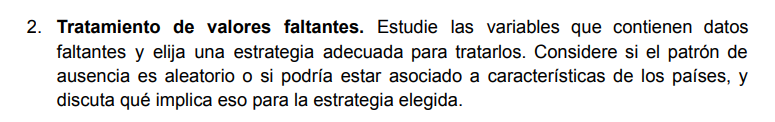

### Conclusiones del EDA — Diagnóstico de valores faltantes

- **MAR temporal confirmado:** `fiscal_health` y `judicial_effectiveness` faltan
  siempre antes de un mismo año de corte (correlación de nulidad = 1 entre
  ambas). La causa es externa y verificable: Heritage Foundation incorporó estos
  dos componentes a su metodología recién a partir de 2017, por lo que las
  observaciones anteriores nunca tuvieron ese dato disponible — no es un
  problema de reporte del país, sino de cobertura temporal de la fuente.

- **MAR temporal sospechado (pendiente de confirmar):** `current_health_expenditure_of_gdp`,
  `primary_energy_consumption_constant_2017_ppp_$`, `labor_freedom` y
  `high-technology_exports_of_manufactured_exports` muestran el mismo patrón
  "peine" (faltante al inicio de la serie de cada país) en la vista ordenada por
  `['country', 'year']`, pero con un año de corte propio, no necesariamente 2017.
  Se decidió verificar el primer año no-nulo por país antes de asumir MAR.

- **Bloques co-publicados:** las columnas de Heritage Foundation (`heritage_score`
  y sus 12 componentes), de Fraser Institute/EFW (`efw_score` y sus áreas) y el
  trío de comercio exterior (`exports_of_goods_and_services_of_gdp`,
  `imports_of_goods_and_services_of_gdp`, `trade_of_gdp`) faltan siempre juntas
  dentro de cada bloque (correlación de nulidad cercana a 1). Esto se explica
  porque cada bloque proviene de un único reporte/cálculo por país-año: si falta
  uno de sus componentes, faltan todos. Queda pendiente verificar si, dentro de
  cada bloque, el faltante es por corte temporal (MAR) o por países enteros sin
  cobertura de esa fuente.

- **Sospecha de MNAR — `poverty_headcount_ratio_at_$1.90_day`,
  `poverty_headcount_ratio_at_$5.50_day` y `gini_index`:** a diferencia de los
  casos anteriores, estas tres faltan en bloques de **países completos** (no en
  un rango de años), lo cual es compatible con que dependan de encuestas de
  hogares que muchos países no levantan con regularidad. Se decidió comparar su
  faltante contra variables de calidad institucional (`heritage_score`,
  `property_rights`, `government_integrity`, `judicial_effectiveness`,
  `legal_system_and_property_rights`) en lugar de contra el propio target,
  porque esas variables institucionales las calcula un organismo externo
  (Heritage Foundation / Fraser Institute) y no dependen de que el país publique
  su propia estadística — evita comparar el faltante contra una fuente que podría
  compartir el mismo mecanismo de generación del dato.

- **Sin patrón claro todavía:** `domestic_credit_to_private_sector_of_gdp`,
  `energy_use_kg_of_oil_equivalent_per_capita`, `freedom_to_trade_internationally`,
  `annual_freshwater_withdrawals_of_internal_resources`, `gross_capital_formation_of_gdp`,
  `real_interest_rate` y el sub-bloque de matrícula escolar
  (`school_enrollment_primary/secondary/tertiary_gross` +
  `government_expenditure_on_education_of_gdp`) muestran correlaciones de
  nulidad bajas con el resto. Se decidió no agruparlas ni clasificarlas todavía
  — revisión individual pendiente antes del inciso de imputación.

- **Próximo paso decidido:** correr tres verificaciones antes de cerrar la
  clasificación — (1) primer año no-nulo por país para el grupo MAR sospechado,
  (2) matriz de nulidad ordenada por país dentro de cada bloque co-publicado,
  (3) comparación estadística (Mann-Whitney) de calidad institucional entre
  países con y sin `poverty_headcount_ratio`/`gini_index` disponible.


## 1.2 Tratamiento de valores faltantes

In [ ]:
from IPython.display import display
from scipy.stats import mannwhitneyu

def primer_anio_no_nulo_por_pais(df, columna):
    return df.dropna(subset=[columna]).groupby('country')['year'].min()


columnas_mar_sospechado = [
    'fiscal_health',
    'judicial_effectiveness',
    'labor_freedom',
    'high-technology_exports_of_manufactured_exports',
    'current_health_expenditure_of_gdp',
    'primary_energy_consumption_constant_2017_ppp_$',
]

columnas_pobreza = [
    'poverty_headcount_ratio_at_$1.90_day_of_population',
    'poverty_headcount_ratio_at_$5.50_day_of_population',
    'gini_index',
]

columnas_institucionales = [
    'judicial_effectiveness',
    'government_integrity',
    'property_rights',
    'legal_system_and_property_rights',
]


def estilizar_tabla(df, columnas_gradiente=None, columnas_gradiente_invertido=None,
                     columnas_gradiente_centrada=None, titulo=None):
    estilo = df.style.hide(axis='index')
    if titulo:
        estilo = estilo.set_caption(titulo)
    if columnas_gradiente:
        # Valor alto = color más intenso (ej. cantidad de países).
        estilo = estilo.background_gradient(subset=columnas_gradiente, cmap='Blues')
    if columnas_gradiente_invertido:
        # Valor BAJO = color más intenso (ej. p-valor: cuanto más chico, más
        # significativo, así que se invierte la escala).
        estilo = estilo.background_gradient(subset=columnas_gradiente_invertido, cmap='Blues_r')
    if columnas_gradiente_centrada:
        # Paleta divergente centrada en 0 para columnas con signo (ej. diferencia
        # de medianas: por encima o por debajo del grupo de referencia).
        limite = df[columnas_gradiente_centrada].abs().max().max()
        estilo = estilo.background_gradient(
            subset=columnas_gradiente_centrada, cmap='coolwarm', vmin=-limite, vmax=limite
        )
    display(estilo.format(precision=3, na_rep='—'))


# -----------------------------------------------------------------------------
# Parte A — tabla de color en vez de value_counts() impreso
# -----------------------------------------------------------------------------
for columna in columnas_mar_sospechado:
    primer_anio = primer_anio_no_nulo_por_pais(df, columna)
    conteo = primer_anio.value_counts().sort_index()
    tabla_primer_anio = pd.DataFrame({
        'primer_anio_con_dato': conteo.index,
        'cantidad_paises': conteo.values,
    })
    estilizar_tabla(
        tabla_primer_anio,
        columnas_gradiente=['cantidad_paises'],
        titulo=f'{columna} — año del primer dato no nulo, por país',
    )


# -----------------------------------------------------------------------------
# Parte C — tabla resumen con color + boxplots con etiquetas cortas
# -----------------------------------------------------------------------------
def comparar_institucionalidad_por_faltante(df, columna_objetivo, columnas_institucionales):
    indicador_faltante = df[columna_objetivo].isna()
    n_total = len(df)
    n_faltante = int(indicador_faltante.sum())

    filas_resumen = []
    figura, ejes = plt.subplots(1, len(columnas_institucionales), figsize=(22, 5))

    for eje, columna_institucional in zip(ejes, columnas_institucionales):
        disponible = df[columna_institucional].notna()
        grupo_faltante = df.loc[disponible & indicador_faltante, columna_institucional]
        grupo_presente = df.loc[disponible & ~indicador_faltante, columna_institucional]

        fila = {
            'variable_institucional': columna_institucional,
            'n_grupo_faltante': len(grupo_faltante),
            'n_grupo_presente': len(grupo_presente),
            'mediana_grupo_faltante': np.nan,
            'mediana_grupo_presente': np.nan,
            'diferencia_mediana': np.nan,
            'p_valor': np.nan,
        }

        # Solapamiento insuficiente: no se calcula el test, pero igual se
        # deja la fila (en blanco) para que quede registrado en la tabla.
        if len(grupo_faltante) < 5 or len(grupo_presente) < 5:
            filas_resumen.append(fila)
            eje.set_visible(False)
            continue

        _, p_valor = mannwhitneyu(grupo_faltante, grupo_presente)
        fila['mediana_grupo_faltante'] = grupo_faltante.median()
        fila['mediana_grupo_presente'] = grupo_presente.median()
        fila['diferencia_mediana'] = fila['mediana_grupo_faltante'] - fila['mediana_grupo_presente']
        fila['p_valor'] = p_valor
        filas_resumen.append(fila)

        datos_grafico = pd.DataFrame({
            columna_institucional: df.loc[disponible, columna_institucional],
            'estado': np.where(indicador_faltante[disponible], 'Faltante', 'Presente'),
        })
        sns.boxplot(data=datos_grafico, x='estado', y=columna_institucional, ax=eje)

        # Etiquetas cortas (antes: nombre completo de la columna + salto de
        # línea en cada tick del eje X, lo que las hacía chocar entre subplots).
        eje.set_ylabel(columna_institucional.replace('_', ' '), fontsize=9)
        eje.set_xlabel('')
        eje.tick_params(axis='x', labelsize=9)
        eje.set_title('')

    plt.suptitle(
        f'Calidad institucional según disponibilidad de {columna_objetivo}\n'
        f'(faltante en {n_faltante} de {n_total} filas, {n_faltante / n_total:.1%})',
        fontsize=11,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

    tabla_resumen = pd.DataFrame(filas_resumen)
    estilizar_tabla(
        tabla_resumen,
        columnas_gradiente_invertido=['p_valor'],
        columnas_gradiente_centrada=['diferencia_mediana'],
        titulo=f'Comparación de calidad institucional — {columna_objetivo}',
    )


for columna_objetivo in columnas_pobreza:
    comparar_institucionalidad_por_faltante(df, columna_objetivo, columnas_institucionales)


In [ ]:
# =============================================================================
# Grupo 3 — Bloques co-publicados: ¿el faltante es un corte temporal (peine)
# o países enteros sin cobertura (bloque sólido)? Se ordena por país primero
# para que un país sin cobertura se vea como una franja horizontal completa.
# =============================================================================
bloque_heritage = [
    'heritage_score', 'property_rights', 'government_integrity',
    'judicial_effectiveness', 'tax_burden', 'government_spending',
    'fiscal_health', 'business_freedom', 'labor_freedom',
    'monetary_freedom', 'trade_freedom', 'investment_freedom',
    'financial_freedom',
]
bloque_efw = [
    'efw_score', 'size_of_government', 'legal_system_and_property_rights',
    'sound_money', 'freedom_to_trade_internationally',
    'regulation_of_credit_labor_and_business',
    'standard_deviation_of_the_5_efw_areas',
]
bloque_comercio = [
    'exports_of_goods_and_services_of_gdp',
    'imports_of_goods_and_services_of_gdp',
    'trade_of_gdp',
]

df_ordenado = df.sort_values(['country', 'year'])

for nombre_bloque, columnas_bloque in [
    ('Heritage Foundation', bloque_heritage),
    ('Fraser Institute (EFW)', bloque_efw),
    ('Comercio exterior', bloque_comercio),
]:
    msno.matrix(df_ordenado[columnas_bloque])
    plt.title(f'Nulidad ordenada por país — bloque {nombre_bloque}')
    plt.show()


# =============================================================================
# Grupo 5 — Columnas sin patrón claro de correlación de nulidad. Se aplican
# los mismos dos chequeos de los grupos anteriores:
# (1) primer año no nulo por país — por si cada una tiene su propio corte
#     temporal individual (y por eso no correlacionan entre sí: años distintos);
# (2) matriz de nulidad ordenada por país — para distinguir disperso (MCAR-like)
#     de concentrado en ciertos países (estructural).
# =============================================================================
columnas_sin_bloque = [
    'domestic_credit_to_private_sector_of_gdp',
    'energy_use_kg_of_oil_equivalent_per_capita',
    'annual_freshwater_withdrawals_of_internal_resources',
    'gross_capital_formation_of_gdp',
    'real_interest_rate',
]

bloque_educacion = [
    'school_enrollment_primary_gross',
    'school_enrollment_secondary_gross',
    'school_enrollment_tertiary_gross',
    'government_expenditure_on_education_of_gdp',
]

# (1) Primer año no nulo por país, reusando la función y la tabla con color
# ya definidas para el grupo 2.
for columna in columnas_sin_bloque + bloque_educacion:
    primer_anio = primer_anio_no_nulo_por_pais(df, columna)
    conteo = primer_anio.value_counts().sort_index()
    tabla_primer_anio = pd.DataFrame({
        'primer_anio_con_dato': conteo.index,
        'cantidad_paises': conteo.values,
    })
    estilizar_tabla(
        tabla_primer_anio,
        columnas_gradiente=['cantidad_paises'],
        titulo=f'{columna} — año del primer dato no nulo, por país',
    )

# (2) Matriz de nulidad ordenada por país, separando el sub-bloque de
# educación (mostró algo de correlación interna, 0.4-0.6) del resto.
msno.matrix(df_ordenado[bloque_educacion])
plt.title('Nulidad ordenada por país — bloque educación')
plt.show()

msno.matrix(df_ordenado[columnas_sin_bloque])
plt.title('Nulidad ordenada por país — columnas sin bloque claro')
plt.show()


In [ ]:
def paises_en_la_cola(df, columna, anio_base=1995):
    """
    Lista los países cuyo primer dato no nulo en `columna` es posterior al
    primer año del panel — para revisar a ojo si el retraso tiene una razón
    histórica plausible en vez de asumir azar.
    """
    primer_anio = primer_anio_no_nulo_por_pais(df, columna)
    cola = primer_anio[primer_anio > anio_base].sort_values()
    tabla_cola = cola.reset_index()
    tabla_cola.columns = ['country', 'primer_anio_con_dato']
    estilo = tabla_cola.style.hide(axis='index').set_caption(
        f'{columna} — países sin dato desde el inicio del panel (1995)'
    )
    display(estilo)

paises_en_la_cola(df, 'real_interest_rate')
paises_en_la_cola(df, 'government_expenditure_on_education_of_gdp')


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

# =============================================================================
# Preparación
# =============================================================================
columnas_identificadoras = ['country', 'year', 'iso_code', 'countryiso3']
columna_target = 'gdp_per_capita_current_us$'
columnas_a_imputar = [
    col for col in df.columns
    if col not in columnas_identificadoras + [columna_target]
]

columnas_mnar_sospechado = [
    'poverty_headcount_ratio_at_$1.90_day_of_population',
    'poverty_headcount_ratio_at_$5.50_day_of_population',
    'gini_index',
]

df_trabajo = df.copy()
# Indicador de faltante original: columnas ya completas (0/1), no entran a
# escalador/KNN (podrían tener IQR=0 y romper el escalado robusto).
for columna in columnas_mnar_sospechado:
    df_trabajo[f'{columna}_era_faltante'] = df_trabajo[columna].isna().astype(int)

#completar iso_code/countryiso3 con el valor fijo del país, antes
# de cualquier otra cosa (no depende de train/test, es solo una búsqueda).
for columna in ['iso_code', 'countryiso3']:
    df_trabajo[columna] = df_trabajo.groupby('country')[columna].transform('first')

# =============================================================================
# Split por país (conglomerados) — 75/25
# =============================================================================
divisor = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
indices_train, indices_test = next(
    divisor.split(df_trabajo, groups=df_trabajo['country'])
)
df_train = df_trabajo.iloc[indices_train].copy()
df_test = df_trabajo.iloc[indices_test].copy()

# Verificación de que ningún país quedó partido entre ambos conjuntos.
assert set(df_train['country']).isdisjoint(set(df_test['country']))
print(f'Países en train: {df_train["country"].nunique()} | '
      f'Países en test: {df_test["country"].nunique()}')


# =============================================================================
# Paso 1 — Relleno temporal por país, aplicado por separado en cada conjunto
# (nunca usa datos del otro conjunto).
# =============================================================================
def rellenar_serie_por_pais(serie):
    return serie.interpolate(method='linear', limit_direction='both')

def aplicar_relleno_temporal(df_subconjunto):
    df_subconjunto = df_subconjunto.sort_values(['country', 'year'])
    df_subconjunto[columnas_a_imputar] = (
        df_subconjunto.groupby('country')[columnas_a_imputar]
        .transform(rellenar_serie_por_pais)
    )
    return df_subconjunto

df_train = aplicar_relleno_temporal(df_train)
df_test = aplicar_relleno_temporal(df_test)


# =============================================================================
# Paso 2 — RobustScaler + KNNImputer: se ajustan SOLO con train, y se aplican
# (transform, no fit) sobre test.
# =============================================================================
escalador = RobustScaler()
train_escalado = escalador.fit_transform(df_train[columnas_a_imputar])
test_escalado = escalador.transform(df_test[columnas_a_imputar])

imputador_knn = KNNImputer(n_neighbors=5)
train_imputado_escalado = imputador_knn.fit_transform(train_escalado)
test_imputado_escalado = imputador_knn.transform(test_escalado)

df_train[columnas_a_imputar] = escalador.inverse_transform(train_imputado_escalado)
df_test[columnas_a_imputar] = escalador.inverse_transform(test_imputado_escalado)

for nombre, subconjunto in [('train', df_train), ('test', df_test)]:
    nulos = subconjunto[columnas_a_imputar].isna().sum().sum()
    assert nulos == 0, f'Quedaron nulos sin resolver en {nombre}: {nulos}'
print('Imputación completa. Nulos restantes:',
      df_train[columnas_a_imputar].isna().sum().sum()
      + df_test[columnas_a_imputar].isna().sum().sum())


# =============================================================================
# Verificación — outliers antes vs. después (diagnóstico final, no afecta el
# ajuste del modelo, así que se hace sobre el dataset ya reunido).
# =============================================================================
df_final = pd.concat([df_train, df_test]).sort_index()

def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((serie < limite_inferior) | (serie > limite_superior)).sum())

filas_resumen_outliers = []
for columna in columnas_a_imputar:
    mascara_original = df[columna].notna()
    outliers_antes = contar_outliers_iqr(df.loc[mascara_original, columna])
    outliers_despues = contar_outliers_iqr(df_final[columna])
    filas_resumen_outliers.append({
        'columna': columna,
        'outliers_antes_de_imputar': outliers_antes,
        'outliers_despues_de_imputar': outliers_despues,
        'outliers_nuevos_por_imputacion': outliers_despues - outliers_antes,
    })

tabla_outliers = pd.DataFrame(filas_resumen_outliers)
estilizar_tabla(
    tabla_outliers,
    columnas_gradiente_centrada=['outliers_nuevos_por_imputacion'],
    titulo='Outliers (criterio 1.5×IQR) antes vs. después de la imputación',
)

df[columna_target].isna().sum()


In [ ]:
df[columna_target].isna().sum() #Hay un faltante en la variable target
fila_sin_target = df_trabajo[df_trabajo[columna_target].isna()]
print('País/año sin target (se excluye del modelado):')
print(fila_sin_target[['country', 'year']])

df_train = df_train[df_train[columna_target].notna()].copy() #Quitamos la observación del dataset.
df_test = df_test[df_test[columna_target].notna()].copy()

print(f'Filas en train: {len(df_train)} | Filas en test: {len(df_test)}')



In [ ]:
# =============================================================================
# Verificación de la imputación — KDE antes/después, tabla de varianza,
# boxplot del trío MNAR. Se compara siempre contra `df` original (con nulos)
# vs. el dataset ya imputado (train+test reunidos SOLO para este chequeo
# descriptivo, no para modelar).
# =============================================================================
df_completo_verificacion = pd.concat([df_train, df_test])

# -----------------------------------------------------------------------------
# 1 — KDE antes/después, una columna representativa por grupo de tratamiento
# -----------------------------------------------------------------------------
def graficar_distribucion_antes_despues(valores_originales, valores_finales, columna, eje):
    """Compara forma y dispersión antes/después — detecta aplastamiento de varianza."""
    sns.kdeplot(valores_originales.dropna(), ax=eje, label='Antes', fill=True, alpha=0.3)
    sns.kdeplot(valores_finales, ax=eje, label='Después', fill=True, alpha=0.3)
    eje.set_title(columna, fontsize=10)
    eje.set_xlabel('')
    eje.legend(fontsize=8)

columnas_ejemplo_kde = [
    'fiscal_health',                              # MAR temporal
    'heritage_score',                             # bloque co-publicado
    'gini_index',                                 # sospecha de MNAR
    'domestic_credit_to_private_sector_of_gdp',   # sin causa clara
]

figura, ejes = plt.subplots(1, 4, figsize=(22, 4))
for eje, columna in zip(ejes, columnas_ejemplo_kde):
    graficar_distribucion_antes_despues(df[columna], df_completo_verificacion[columna], columna, eje)
plt.suptitle('Distribución antes vs. después de imputar (muestra representativa)')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 2 — Tabla de cambio en el desvío estándar, todas las columnas imputadas
# -----------------------------------------------------------------------------
filas_resumen_varianza = []
for columna in columnas_a_imputar:
    desvio_antes = df.loc[df[columna].notna(), columna].std()
    desvio_despues = df_completo_verificacion[columna].std()
    cambio_relativo = (
        (desvio_despues - desvio_antes) / desvio_antes if desvio_antes not in (0, None) else np.nan
    )
    filas_resumen_varianza.append({
        'columna': columna,
        'desvio_antes': desvio_antes,
        'desvio_despues': desvio_despues,
        'cambio_relativo_desvio': cambio_relativo,
    })

tabla_varianza = pd.DataFrame(filas_resumen_varianza)
estilizar_tabla(
    tabla_varianza,
    columnas_gradiente_centrada=['cambio_relativo_desvio'],
    titulo='Cambio en el desvío estándar antes vs. después de imputar',
)

# -----------------------------------------------------------------------------
# 3 — Boxplot antes/después, trío sospechoso de MNAR
# -----------------------------------------------------------------------------
figura, ejes = plt.subplots(1, len(columnas_mnar_sospechado), figsize=(18, 5))
for eje, columna in zip(ejes, columnas_mnar_sospechado):
    datos_antes = pd.DataFrame({columna: df.loc[df[columna].notna(), columna], 'momento': 'Antes'})
    datos_despues = pd.DataFrame({columna: df_completo_verificacion[columna], 'momento': 'Después'})
    datos_comparacion = pd.concat([datos_antes, datos_despues])
    sns.boxplot(data=datos_comparacion, x='momento', y=columna, ax=eje)
    eje.set_xlabel('')
plt.suptitle('Boxplot antes vs. después — trío sospechoso de MNAR')
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# Verificación 4 — Serie temporal de un país, marcando qué puntos eran
# faltantes y se completaron en el Paso 1 (relleno temporal por país).
# =============================================================================
def graficar_serie_pais(df_original, df_final, pais, columna):
    """Chequeo visual: ¿el relleno temporal da valores razonables para este país?"""
    serie_original = df_original[df_original['country'] == pais].sort_values('year').reset_index(drop=True)
    serie_final = df_final[df_final['country'] == pais].sort_values('year').reset_index(drop=True)
    eran_faltantes = serie_original[columna].isna().values

    plt.figure(figsize=(10, 4))
    plt.plot(serie_final['year'], serie_final[columna], color='gray', linewidth=1, zorder=1)
    plt.scatter(
        serie_final.loc[~eran_faltantes, 'year'], serie_final.loc[~eran_faltantes, columna],
        color='steelblue', label='Dato real', zorder=2,
    )
    plt.scatter(
        serie_final.loc[eran_faltantes, 'year'], serie_final.loc[eran_faltantes, columna],
        color='crimson', label='Completado (Paso 1)', zorder=2,
    )
    plt.title(f'{columna} — {pais}: dato real vs. completado')
    plt.xlabel('year')
    plt.ylabel(columna)
    plt.legend()
    plt.tight_layout()
    plt.show()

graficar_serie_pais(df, df_completo_verificacion, 'Argentina', 'fiscal_health') #Se interpolan los datos para no hacer suposiciones
#infundadas sobre tendencias pasadas. Muchos países se ven coomo una línea plana de datos interpolados (no necesariamente está mal).

def encontrar_ejemplo_hueco_interno(df, columnas):
    """Busca un país-columna con un hueco EN EL MEDIO (dato real antes y
    después, faltante en el medio) — para mostrar la interpolación con
    pendiente, distinta al relleno de extremos que se vio con Albania."""
    for columna in columnas:
        for pais, grupo in df.groupby('country'):
            serie = grupo.sort_values('year')[columna].reset_index(drop=True)
            es_nulo = serie.isna().values
            if len(serie) < 3 or es_nulo[0] or es_nulo[-1]:
                continue
            if es_nulo[1:-1].any():
                return pais, columna
    return None, None

pais_ejemplo, columna_ejemplo = encontrar_ejemplo_hueco_interno(df, columnas_a_imputar)
#print(f'Ejemplo con hueco interno: {pais_ejemplo} — {columna_ejemplo}')

graficar_serie_pais(df, df_completo_verificacion, pais_ejemplo, columna_ejemplo)



### Conclusiones sobre valores faltantes
- **Diagnóstico previo del mecanismo por bloque** (matrices y correlación de
  nulidad con `missingno`): MAR temporal confirmado en `fiscal_health`,
  `judicial_effectiveness`, `current_health_expenditure_of_gdp`,
  `primary_energy_consumption_constant_2017_ppp_$` y `labor_freedom` (cada
  una con su propio corte por año de inicio de cobertura); bloques
  co-publicados (Heritage: 12 columnas, Fraser/EFW: 7, comercio exterior: 3)
  que faltan juntas por venir de un único reporte; y sospecha fuerte de MNAR
  en `poverty_headcount_ratio` (x2) y `gini_index`, cuyo faltante correlaciona
  con peor calidad institucional (Mann-Whitney significativo).
- **Tratamiento en dos pasos:** relleno temporal por país (interpolación en
  huecos internos, relleno al extremo más cercano en huecos de borde) y
  luego `KNNImputer` (con `RobustScaler` previo) entre países solo para lo
  que quedó sin resolver. Para el trío MNAR se agregó un indicador binario
  de faltante original antes de imputar.
- **Split por país** (`GroupShuffleSplit`, 75/25, `random_state=42`) antes de
  ajustar cualquier estadístico — evita fuga y mide generalización a países
  nunca vistos (108 train / 36 test). Se eliminó además la única fila con
  target faltante.
- **Resultado:** `df_train`/`df_test` sin nulos, entregados separados para
  que 1.3/1.4 no reintroduzcan fuga.
- **Verificación:** KDE y boxplot antes/después, tabla de cambio de desvío
  estándar (60 columnas) y series de país de ejemplo. Hallazgo clave: en
  columnas con hueco solo al principio (el indicador no existía antes de
  cierto año), el relleno queda constante en ese tramo en vez de simular una
  tendencia — la opción más honesta, pero implica cero variación año a año
  ahí. El trío MNAR sigue siendo el tratamiento menos confiable del dataset.


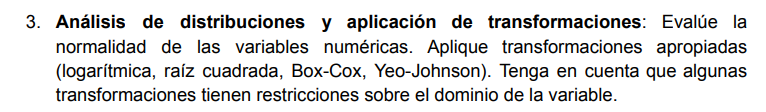

## 1.3 Transformaciones

**OBSERVACIÓN**: Las transformaciones aplicadas en este ejercicio no deben entenderse
como una modificación definitiva del dataset. A lo largo de los ejercicios siguientes se
trabajará alternadamente con las variables en su escala original y con las variables
transformadas, según lo requiera cada técnica.

In [ ]:
from scipy import stats
from scipy.stats.mstats import winsorize

# Guardamos una copia de los datos originales
df_train_original = df_train.copy()

def winsorizar_1_99(serie):

    serie_tratada = serie.copy()
    mascara_validos = serie.notna()

    serie_tratada[mascara_validos] = winsorize(
        serie[mascara_validos], limits=[0.01, 0.01]
    )
    return serie_tratada

def evaluar_transformaciones(df, variable):
    # Sacamos los nulos temporalmente para evaluar las transformaciones
    serie = df[variable].dropna()
    min_val = serie.min()
    transformaciones = {'Original': serie}

    # Yeo-Johnson
    transformaciones['Yeo-Johnson'], _ = stats.yeojohnson(serie)

    if min_val >= 0:
        # Raíz cuadrada
        transformaciones['Raíz Cuadrada'] = np.sqrt(serie)

        # Logarítmica
        transformaciones['Logarítmica (log1p)'] = np.log1p(serie)

    if min_val > 0:
        # Box-Cox
        transformaciones['Box-Cox'], _ = stats.boxcox(serie)

    n_transf = len(transformaciones)
    fig, axes = plt.subplots(2, n_transf, figsize=(4 * n_transf, 8))

    for i, (nombre, datos_transf) in enumerate(transformaciones.items()):
        skewness = stats.skew(datos_transf)

        sns.histplot(datos_transf, kde=True, ax=axes[0, i], color='#4C72B0')
        axes[0, i].set_title(f'{nombre}\nSkew: {skewness:.2f}', fontsize=10)
        axes[0, i].set_xlabel('')

        stats.probplot(datos_transf, dist="norm", plot=axes[1, i])
        axes[1, i].set_title('')
        axes[1, i].set_xlabel('Cuantiles Teóricos')

        if i > 0:
            axes[1, i].set_ylabel('')

    plt.suptitle(
        f'Análisis de Transformaciones para: {variable}',
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()



for col in vars_asimetricas:
    df_train[col] = winsorizar_1_99(df_train[col])
    evaluar_transformaciones(df_train, col)


# Aplicamos Box-Cox de forma definitiva
for col in vars_asimetricas:

    serie = df_train[col].dropna()
    min_val = serie.min()

    if min_val > 0:
        df_train.loc[serie.index, col] = stats.boxcox(serie)[0]

    else:
        constante = abs(min_val) + 1
        df_train.loc[serie.index, col] = stats.boxcox(serie + constante)[0]

print("¡Listo! Las variables asimétricas fueron winsorizadas y transformadas.")


## 1.4 Estandarización

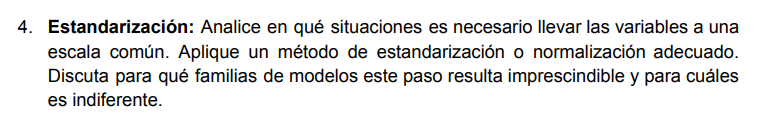

Es conveniente llevar las variables a una escala común cuando el algoritmo utilizado es sensible a la magnitud de las variables de entrada. Esto ocurre, por ejemplo, con los métodos basados en distancias, como K-vecinos más cercanos (K-NN), K-medias y las máquinas de vectores de soporte (SVM). En estos casos, una variable cuyos valores se encuentran en un rango mucho mayor puede dominar el cálculo de las distancias, haciendo que otras variables tengan una influencia menor, no porque sean menos informativas, sino simplemente porque están expresadas en una escala numéricamente menor.

La estandarización también resulta conveniente en modelos optimizados mediante métodos basados en descenso por gradiente, tales como las redes neuronales. Cuando las variables presentan escalas muy diferentes, la superficie de la función de costo puede adquirir una geometría alargada, dificultando el proceso de optimización y haciendo que el algoritmo avance de manera menos eficiente. Llevar las variables a escalas comparables favorece una convergencia más rápida y estable.

Por otra parte, la escala de las variables es relevante en métodos basados en la varianza, como PCA. Si las variables no se estandarizan, aquellas que presentan una mayor variabilidad numérica pueden dominar la varianza total y, por lo tanto, tener una influencia desproporcionada en los componentes principales.



In [ ]:
import pandas as pd

from sklearn.preprocessing import RobustScaler

#Separación de variables predictoras y variable objetivo

columna_objetivo = "gdp_per_capita_current_us$"

X_train = df_train.drop(columns=[columna_objetivo])
y_train = df_train[columna_objetivo].copy()

X_test = df_test.drop(columns=[columna_objetivo])
y_test = df_test[columna_objetivo].copy()

columnas_numericas = X_train.select_dtypes(include="number").columns.tolist()


#Aplicamos RobustScaler solo en train

robust_scaler = RobustScaler()

X_train_robust = X_train.copy()
X_test_robust = X_test.copy()

X_train_robust[columnas_numericas] = robust_scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test_robust[columnas_numericas] = robust_scaler.transform(
    X_test[columnas_numericas]
)

#Reincorporamos la variable objetivo

X_train_robust[columna_objetivo] = y_train
X_test_robust[columna_objetivo] = y_test

#DATASET FINAL DESPUES DEL ESCALADO
df_robust = pd.concat(
    [X_train_robust, X_test_robust]
).sort_index()

Dado que en la consigna no se especifica explicitamente realizar un analisis de outliers, se analizaron las variables principales y en base a las mismas se decidio un metodo de escalado.
Algunas de estas variables presentan atipicos que consideramos son validos en el dominio del problema y por eso se decidio conservarlos.
De esta manera, se aplicó robustScaler() por ser un metodo robusto ante la presencia de los mismos

Este paso resulta imprescindible para todas aquellas familias de modelos que se basan en distancias, productos internos o medidas de varianza ya que son sensibles a las escalas de las features. Dentro de este grupo se encuentran los métodos basados en distancia, como K-NN y K-medias; las máquinas de vectores de soporte; los métodos de reducción de dimensionalidad basados en varianza, como PCA; y numerosos modelos optimizados mediante descenso por gradiente, como las redes neuronales y las regresiones regularizadas. En estos casos, la estandarización suele ser necesaria o altamente recomendable para evitar que las diferencias de unidades o magnitudes condicionen el comportamiento del modelo.

Por el contrario, existen familias de modelos que por su funcionamiento resultan prácticamente invariantes ante cambios de escala. El ejemplo más representativo son los modelos basados en árboles, como los árboles de decisión, Random Forest y los métodos de boosting.


# Ejercicio 2

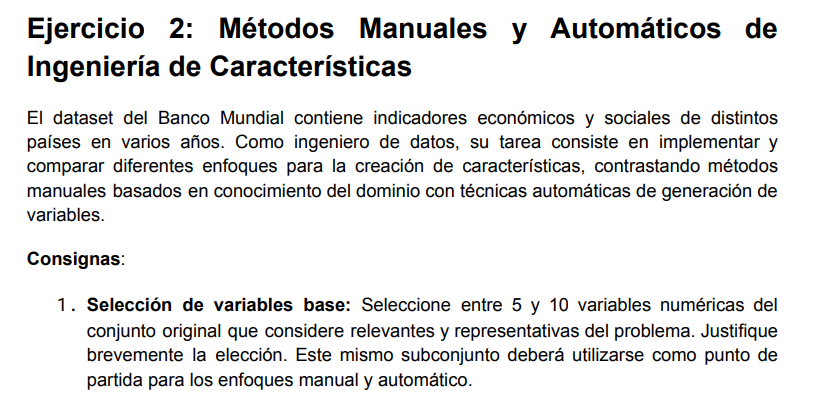

## 2.1 Selección de variables numéricas

In [ ]:
columnas_dendrograma = [
    c for c in df_train.columns
    if c not in COLUMNAS_ID + ['year'] and not c.endswith('_era_faltante')
]
matriz_corr_train = calcular_matriz_correlacion(df_train, columnas_dendrograma)

graficar_dendrograma_correlacion(matriz_corr_train,
    'Dendrograma de correlación entre features (dataset imputado, train)')


In [ ]:
correlacion_target_train = df_train[columnas_dendrograma].corr(numeric_only=True)[TARGET].drop(TARGET)
correlacion_target_train = correlacion_target_train.reindex(
    correlacion_target_train.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 14))
colores = ['#4C72B0' if v > 0 else '#C44E52' for v in correlacion_target_train.values]
ax.barh(correlacion_target_train.index[::-1], correlacion_target_train.values[::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Correlacion de Pearson con {TARGET} (train, imputado)')
ax.set_title('Correlacion de cada variable numerica con el target — dataset ya completo')
plt.tight_layout()
plt.show()


Intuición: creemos que las variables asociadas a la estabilidad política y económica serán muy importantes para predecir el pbi per cápita de una nación. Sin embargo, agregar muchas de estas features (principalmente las asociadas al heritage score y efw score) haría que entre sí sean bastante redundantes. Por eso se optó por escoger las 10 variables con más correlación con la feature target y más separadas entre sí en el dendrograma.

In [ ]:
from scipy.cluster.hierarchy import fcluster

variables_excluidas_por_fuga = [TARGET, 'gdp_current_us$','gdp_ppp_current_international_$','gdp_growth_annual','gdp_per_capita_growth_annual']
# 'gdp_ppp_current_international_$' tiene el mismo problema (es PBI total,
# no per capita) - agregala a la lista de arriba si también la querés sacar.

columnas_seleccion = [c for c in columnas_dendrograma if c not in variables_excluidas_por_fuga]

matriz_corr_seleccion = calcular_matriz_correlacion(df_train, columnas_seleccion)

distancia = (1 - matriz_corr_seleccion.abs()).to_numpy().copy()
np.fill_diagonal(distancia, 0)
distancia_condensada = squareform(distancia, checks=False)
enlaces_seleccion = linkage(distancia_condensada, method='average')

corr_abs_target = df_train[columnas_seleccion].corrwith(df_train[TARGET]).abs()

def representantes_por_cluster(k):
    clusters = fcluster(enlaces_seleccion, t=k, criterion='maxclust')
    asignacion = pd.Series(clusters, index=matriz_corr_seleccion.columns)
    filas = []
    for cluster_id in sorted(asignacion.unique()):
        miembros = asignacion[asignacion == cluster_id].index.tolist()
        representante = corr_abs_target.loc[miembros].idxmax()
        filas.append({
            'representante': representante,
            'corr_abs_con_target': corr_abs_target[representante],
            'n_miembros_del_cluster': len(miembros),
            'miembros': miembros,
        })
    return pd.DataFrame(filas).sort_values('corr_abs_con_target', ascending=False).reset_index(drop=True)

#display(representantes_por_cluster(5)[['representante', 'corr_abs_con_target', 'n_miembros_del_cluster']])
display(representantes_por_cluster(10)[['representante', 'corr_abs_con_target', 'n_miembros_del_cluster']])


In [ ]:
tabla_top10 = representantes_por_cluster(10)

variables_seleccionadas = tabla_top10['representante'].iloc[:9].tolist()
variables_seleccionadas.append('heritage_score')

for i, variable in enumerate(variables_seleccionadas):
  print(f"Feature {i+1}: {variable}")


* Criterio de selección (9 variables automáticas): partimos de un dendrograma
de correlación entre las ~57 variables numéricas del dataset (excluyendo el target y las variables de PBI total, que filtramos por representar casi directamente al target). Agrupamos esas variables en 10 clusters según qué tan parecidas son entre sí (features que correlacionan fuerte entre ellas quedan en el mismo grupo), y de cada cluster nos quedamos con la variable más correlacionada con gdp_per_capita_current_us$. Esto asegura que las 9 variables elegidas no sean redundantes entre sí. Cada una viene de una zona distinta del espacio de features.

* Por qué agregamos heritage_score como décima variable: decidimos reemplazar manualmente la variable de menor correlación (personal_remittances_received_current_us$, prácticamente sin relación con el target) por heritage_score. Esta variable es el promedio de doce sub-índices vinculados a la estabilidad política, institucional y económica de un país (propiedad, integridad de gobierno, libertad de inversión, entre otros), un aspecto que consideramos clave para explicar el PBI per cápita.

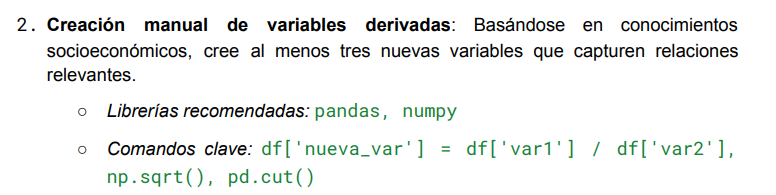

## 2.2 Creación manual de variables derivadas

In [ ]:
def crear_features_sin_fit(df):
    """Features con formula cerrada o umbrales fijos de dominio: no dependen
    de ningun parametro aprendido de los datos, se aplican igual en train y test."""
    df = df.sort_values(['country', 'year']).copy()

    df['peso_exportaciones_tech_en_pbi'] = (
        df['high-technology_exports_of_manufactured_exports'] / 100
        * df['exports_of_goods_and_services_of_gdp'] / 100
    ) * 100

    df['categoria_pobreza'] = pd.cut(
        df['poverty_headcount_ratio_at_$5.50_day_of_population'],
        bins=[-0.01, 15, 40, 100], labels=['Baja', 'Media', 'Alta']
    )

    df['categoria_estres_hidrico'] = pd.cut(
        df['annual_freshwater_withdrawals_of_internal_resources'],
        bins=[-0.01, 25, 70, float('inf')], labels=['Bajo', 'Medio', 'Severo']
    )

    fdi = df['foreign_direct_investment_net_inflows_current_us$']
    df['fdi_log_signado'] = np.sign(fdi) * np.log1p(fdi.abs())
    df['direccion_fdi'] = np.where(fdi >= 0, 'Entrada neta', 'Salida neta')

    df['variacion_fdi_interanual'] = (
        df.groupby('country')['fdi_log_signado'].diff().fillna(0)
    )
    return df

df_train = crear_features_sin_fit(df_train)
df_test = crear_features_sin_fit(df_test)


* peso_exportaciones_tech_en_pbi: combina dos ratios existentes porque no hay una base "exportaciones totales" en el dataset para dividir directamente.
* categoria_pobreza: aplica umbrales estándar de líneas de pobreza para capturar el efecto no lineal de la pobreza.
* categoria_estres_hidrico: usa la clasificación de estrés hídrico FAO/ONU sobre una variable que ya es % de recurso renovable.
* fdi_log_signado: comprime la escala extrema de la inversión extranjera directa preservando si fue entrada o salida neta.
* direccion_fdi: señal cualitativa de entrada/salida neta de capital, sin necesitar normalizar por tamaño de país.
* variacion_fdi_interanual: mide si el flujo de capital se acelera o frena año a año, evitando la inestabilidad de un % de cambio directo.

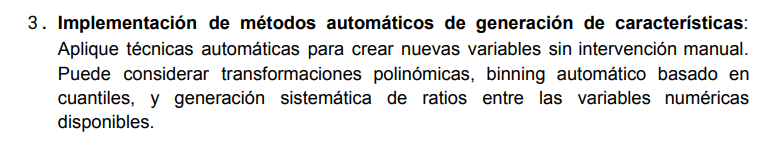

## 2.3 Generación automática de variables

In [ ]:
#Binning por cuantiles
from sklearn.preprocessing import KBinsDiscretizer

discretizador = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
discretizador.fit(df_train[variables_seleccionadas])  # fit solo en train

nombres_bins = [f'{col}_bin_automatico' for col in variables_seleccionadas]

bins_train = pd.DataFrame(discretizador.transform(df_train[variables_seleccionadas]),
                           columns=nombres_bins, index=df_train.index)
bins_test = pd.DataFrame(discretizador.transform(df_test[variables_seleccionadas]),
                          columns=nombres_bins, index=df_test.index)

df_train = df_train.drop(columns=[c for c in nombres_bins if c in df_train.columns])
df_test = df_test.drop(columns=[c for c in nombres_bins if c in df_test.columns])
df_train = pd.concat([df_train, bins_train], axis=1)
df_test = pd.concat([df_test, bins_test], axis=1)



In [ ]:
#Transformaciones polinómicas: 55 features nuevas a partir de las 10 originales (10 cuadrados + 45 interacciones)
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(df_train[variables_seleccionadas])  # fit solo en train

nombres_poly = poly.get_feature_names_out(variables_seleccionadas)
columnas_poly_nuevas = [c for c in nombres_poly if c not in variables_seleccionadas]

poly_train = pd.DataFrame(poly.transform(df_train[variables_seleccionadas]),
                           columns=nombres_poly, index=df_train.index)
poly_test = pd.DataFrame(poly.transform(df_test[variables_seleccionadas]),
                          columns=nombres_poly, index=df_test.index)

df_train = df_train.drop(columns=[c for c in columnas_poly_nuevas if c in df_train.columns])
df_test = df_test.drop(columns=[c for c in columnas_poly_nuevas if c in df_test.columns])
df_train = pd.concat([df_train, poly_train[columnas_poly_nuevas]], axis=1)
df_test = pd.concat([df_test, poly_test[columnas_poly_nuevas]], axis=1)



In [ ]:
#Ratios
import itertools

denominadores_validos = [
    col for col in variables_seleccionadas
    if df_train[col].min() > 0
]

def generar_ratios(df, columnas, denominadores):
    df = df.copy()
    for var_a, var_b in itertools.combinations(columnas, 2):
        if var_a in denominadores:
            df[f'ratio_{var_b}_sobre_{var_a}'] = df[var_b] / df[var_a]
        if var_b in denominadores:
            df[f'ratio_{var_a}_sobre_{var_b}'] = df[var_a] / df[var_b]
    return df

df_train = generar_ratios(df_train, variables_seleccionadas, denominadores_validos)
df_test = generar_ratios(df_test, variables_seleccionadas, denominadores_validos)


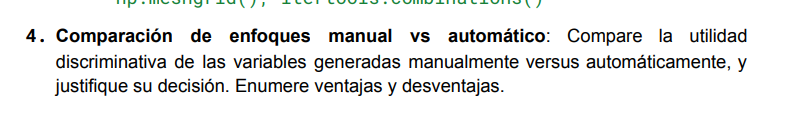

## 2.4 Comparación manual vs. automático

In [ ]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

# Salvaguarda: por si alguna celda de arriba se corrio mas de una vez,
# nos aseguramos de no tener columnas duplicadas antes de calcular MI.
df_train = df_train.loc[:, ~df_train.columns.duplicated(keep='last')]
df_test = df_test.loc[:, ~df_test.columns.duplicated(keep='last')]

variables_manuales = [
    'peso_exportaciones_tech_en_pbi', 'categoria_pobreza', 'categoria_estres_hidrico',
    'fdi_log_signado', 'direccion_fdi', 'variacion_fdi_interanual',
]
columnas_bin_automatico = [f'{col}_bin_automatico' for col in variables_seleccionadas]
columnas_ratios = [c for c in df_train.columns if c.startswith('ratio_')]
variables_automaticas = columnas_poly_nuevas + columnas_bin_automatico + columnas_ratios

def calcular_utilidad_discriminativa(df, columnas, target):
    df_cod = df[columnas].copy()
    categoricas = df_cod.select_dtypes(exclude='number').columns.tolist()
    es_discreta = [c in categoricas or c.endswith('_bin_automatico') for c in columnas]

    if categoricas:
        df_cod[categoricas] = OrdinalEncoder().fit_transform(df_cod[categoricas].astype(str))

    mi = mutual_info_regression(df_cod, df[target], discrete_features=es_discreta, random_state=42)
    return pd.Series(mi, index=columnas).sort_values(ascending=False)

utilidad_manual = calcular_utilidad_discriminativa(df_train, variables_manuales, TARGET)
utilidad_automatica = calcular_utilidad_discriminativa(df_train, variables_automaticas, TARGET)


In [ ]:
utilidad_original = calcular_utilidad_discriminativa(df_train, variables_seleccionadas, TARGET)

tabla_comparacion = pd.concat([
    utilidad_original.rename('mutual_info').to_frame().assign(origen='Original'),
    utilidad_manual.rename('mutual_info').to_frame().assign(origen='Manual'),
    utilidad_automatica.rename('mutual_info').to_frame().assign(origen='Automático'),
]).sort_values('mutual_info', ascending=False)

colores_origen = {'Original': '#C44E52', 'Manual': '#4C72B0', 'Automático': '#55A868'}
orden_origen = ['Original', 'Manual', 'Automático']

####Tabla
resumen_mi = pd.DataFrame({
    'Información mutua promedio': [utilidad_original.mean(), utilidad_manual.mean(), utilidad_automatica.mean()],
    'Información mutua máxima': [utilidad_original.max(), utilidad_manual.max(), utilidad_automatica.max()],
    'Mejor variable': [utilidad_original.idxmax(), utilidad_manual.idxmax(), utilidad_automatica.idxmax()],
}, index=orden_origen).rename_axis('Origen').reset_index()

estilizar_tabla(
    resumen_mi,
    columnas_gradiente=['Información mutua promedio', 'Información mutua máxima'],
    titulo='Comparación original vs. manual vs. automático — información mutua con el target',
)

conteo_top10 = tabla_comparacion.head(10)['origen'].value_counts().reindex(orden_origen).fillna(0)

fig, ax = plt.subplots(figsize=(5, 2.5))
ax.barh(conteo_top10.index, conteo_top10.values, color=[colores_origen[o] for o in conteo_top10.index])
ax.set_xlabel('Cantidad de variables')
ax.set_title('Origen de las 10 variables más útiles (top 10 global)')
for i, v in enumerate(conteo_top10.values):
    ax.text(v + 0.05, i, str(int(v)), va='center')
ax.set_xlim(0, conteo_top10.max() + 1)
plt.tight_layout()
plt.show()
#########

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=tabla_comparacion.reset_index(), x='origen', y='mutual_info', ax=ax,
            order=orden_origen, hue='origen', palette=colores_origen, legend=False)
sns.stripplot(data=tabla_comparacion.reset_index(), x='origen', y='mutual_info', ax=ax,
              order=orden_origen, color='black', alpha=0.4)
ax.set_title('Información mutua con el target: original vs. manual vs. automático')
plt.tight_layout()
plt.show()


In [ ]:
#Las automáticas, aparentemente, son las que más información mutua obtuvieron. Pero veamos si entre sí son redudantes o no
def redundancia_promedio(df, columnas):
    """Correlacion absoluta promedio entre pares del mismo grupo (excluye la
    diagonal) - mide cuanto se repiten entre si, no la relacion con el target."""
    columnas_numericas_grupo = df[columnas].select_dtypes(include='number').columns.tolist()
    if len(columnas_numericas_grupo) < 2:
        return np.nan
    matriz_corr = df[columnas_numericas_grupo].corr().abs()
    np.fill_diagonal(matriz_corr.values, np.nan)
    return matriz_corr.stack().mean()

redundancia_original = redundancia_promedio(df_train, variables_seleccionadas)
redundancia_manual = redundancia_promedio(df_train, variables_manuales)
redundancia_automatica = redundancia_promedio(df_train, variables_automaticas)

resumen_mi['Redundancia interna (|corr| promedio)'] = [
    redundancia_original, redundancia_manual, redundancia_automatica
]

estilizar_tabla(
    resumen_mi,
    columnas_gradiente=['Información mutua promedio', 'Información mutua máxima'],
    columnas_gradiente_invertido=['Redundancia interna (|corr| promedio)'],
    titulo='Comparación original vs. manual vs. automático — relevancia y redundancia',
)


Limitación: esto solo mide correlación lineal entre variables numéricas del grupo. Por otra parte, categoria_pobreza, direccion_fdi y categoria_estres_hidrico (categóricas) quedan afuera del cálculo, así que la redundancia del grupo manual está subestimada (mide redundancia solo entre las 3 numéricas: peso_exportaciones_tech_en_pbi, fdi_log_signado, variacion_fdi_interanual).

Ventajas y desventajas del método manual y automático:

**Manual**

 Mayor interpretabilidad

Menor riesgo de redundancia/ratios sin sentido (según cómo seleccionamos las features).
Una buena feature extraída manualmente depende de un buen conocimiento de dominio del analista.

Poco escalable: pocas variables pueden llevar varias iteraciones de diseño.


**Automático**

Fácilmente escalable.
Puede encontrar relaciones no obvias (interacciones/no-linealidades que nadie propondría a mano).

Riesgo de mucha redundancia (varios ratios comparten numerador/denominador, van a correlacionar fuerte entre sí).

Riesgo de correlaciones espurias por pura cantidad (con 150 intentos, algunas van a parecer "buenas" por azar).

In [ ]:
#Elegimos las k mejores features en base a la mayor informacion mutua con la target y menor redundancia
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder


def _es_discreta(col, df):
    """Mismo criterio de discretitud que ya usa calcular_utilidad_discriminativa
    (celda anterior): no numerica (categorica/object/string, sea cual sea el
    dtype exacto que use pandas para texto), o binning por cuantiles (pocos
    valores). Se usa is_numeric_dtype en vez de comparar dtype.name contra
    'object' porque el nombre del dtype de texto varia entre versiones de
    pandas (ej. 'object' vs 'str' en pandas 3.x) - is_numeric_dtype es estable."""
    return not pd.api.types.is_numeric_dtype(df[col]) or col.endswith('_bin_automatico')


def _mi_entre_features(df, var_a, var_b, cache):
    """MI(var_a; var_b) robusta a los 3 casos que existen en este dataset:
    numerica-numerica, numerica-categorica y categorica-categorica.
    Cachea por par (no ordenado) porque la MI es simetrica y no cambia
    durante el algoritmo de seleccion."""
    clave = tuple(sorted((var_a, var_b)))
    if clave in cache:
        return cache[clave]

    pareja = df[[var_a, var_b]].dropna()
    a, b = pareja[var_a], pareja[var_b]
    a_disc, b_disc = _es_discreta(var_a, df), _es_discreta(var_b, df)

    # Encoding a enteros SOLO como etiqueta nominal de clase (nunca como
    # magnitud continua): por eso el resultado se usa como y de clasificacion
    # o como input de mutual_info_score, nunca como feature numerica.
    if a_disc and not pd.api.types.is_numeric_dtype(a):
        a = LabelEncoder().fit_transform(a.astype(str))
    if b_disc and not pd.api.types.is_numeric_dtype(b):
        b = LabelEncoder().fit_transform(b.astype(str))

    if a_disc and b_disc:
        mi = mutual_info_score(a, b)
    elif a_disc:
        mi = mutual_info_classif(np.asarray(b).reshape(-1, 1), a,
                                  discrete_features=False, random_state=42)[0]
    elif b_disc:
        mi = mutual_info_classif(np.asarray(a).reshape(-1, 1), b,
                                  discrete_features=False, random_state=42)[0]
    else:
        mi = mutual_info_regression(np.asarray(a).reshape(-1, 1), b,
                                     discrete_features=False, random_state=42)[0]

    cache[clave] = mi
    return mi


def seleccionar_mejores_features(df, candidatos, mi_scores, k):
    """
    Seleccion greedy tipo mRMR (Maximum Relevance - Minimum Redundancy).

    Maximum Relevance:
        I(feature, target)            -> mi_scores[var], ya calculado antes
    Minimum Redundancy:
        promedio de I(feature, ya_seleccionadas), usando informacion mutua
        (no correlacion de Pearson) para cubrir pares numerico-numerico,
        numerico-categorico y categorico-categorico sin asumir linealidad
        ni inventar un orden numerico en las categoricas.

    Score(X) = I(X;Y) - (1/|S|) * sum_{Z in S} I(X;Z)
    """
    seleccionadas = []
    restantes = list(candidatos)

    # Primera variable: la de mayor informacion mutua individual (todavia
    # no hay nada elegido contra que comparar redundancia).
    primera = mi_scores.loc[restantes].idxmax()
    seleccionadas.append(primera)
    restantes.remove(primera)

    cache_mi_pares = {}

    while len(seleccionadas) < k and restantes:
        puntajes = {}
        for var in restantes:
            relevancia = mi_scores[var]
            mi_con_seleccionadas = [
                _mi_entre_features(df, var, elegida, cache_mi_pares)
                for elegida in seleccionadas
            ]
            redundancia = np.mean(mi_con_seleccionadas)
            puntajes[var] = relevancia - redundancia  # Score para cada variable

        siguiente = max(puntajes, key=puntajes.get)
        seleccionadas.append(siguiente)
        restantes.remove(siguiente)

    return seleccionadas


todas_las_candidatas = variables_seleccionadas + variables_manuales + variables_automaticas
mi_todas = tabla_comparacion['mutual_info']

k = 10  # ajustar al numero que necesites
mejores_k = seleccionar_mejores_features(df_train, todas_las_candidatas, mi_todas, k)

tabla_seleccion_final = tabla_comparacion.loc[mejores_k].reset_index().rename(columns={'index': 'variable'})
estilizar_tabla(
    tabla_seleccion_final,
    columnas_gradiente=['mutual_info'],
    titulo=f'{k} variables finales - relevancia maxima, redundancia minima (mRMR con informacion mutua)',
)

# Que cambio y por que:
# - Antes, la redundancia entre una candidata y las ya elegidas se medveia con
#   correlacion de Pearson, y solo entre pares numericos (las categoricas no
#   penalizaban ni favorecian nunca, quedaban afuera del calculo).
# - Ahora la redundancia es el promedio de informacion mutua I(X;Z) contra
#   cada feature ya seleccionada, calculada con el estimador correcto segun
#   el tipo real de cada par (numerica-numerica, numerica-categorica o
#   categorica-categorica) via _mi_entre_features. Esto es mRMR real: cubre
#   relaciones no lineales y no ignora a las variables categoricas del
#   dataset (categoria_pobreza, categoria_estres_hidrico, direccion_fdi).


# Ejercicio 3

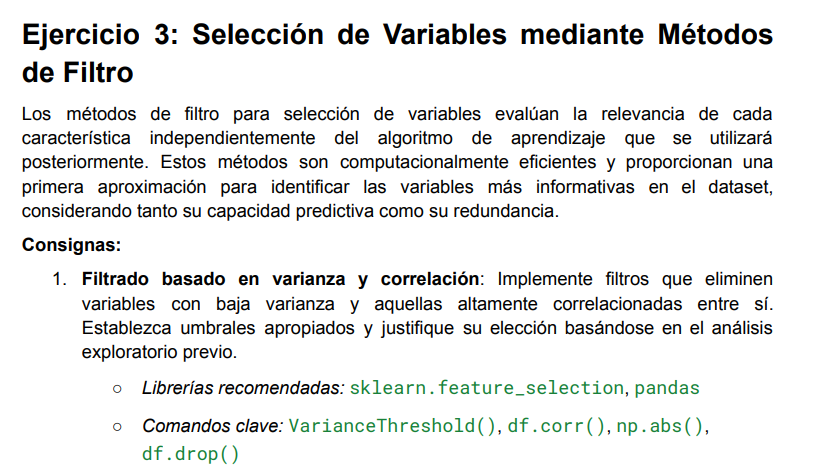

## 3.1 Filtrado por varianza y correlación

In [ ]:
from sklearn.feature_selection import VarianceThreshold

numeric_features = [    'year', 'heritage_score','property_rights','government_integrity','judicial_effectiveness','tax_burden','government_spending',
    'fiscal_health','business_freedom','labor_freedom','monetary_freedom', 'trade_freedom','investment_freedom','financial_freedom','efw_score',
    'size_of_government','legal_system_and_property_rights','sound_money','freedom_to_trade_internationally','regulation_of_credit_labor_and_business',
    'standard_deviation_of_the_5_efw_areas', 'access_to_electricity_of_population','adult_literacy_rate_of_people_ages_15_and_above','agriculture_value_added_of_gdp',
    'annual_freshwater_withdrawals_of_internal_resources','central_government_debt_of_gdp', 'current_health_expenditure_of_gdp','domestic_credit_to_private_sector_of_gdp',
    'energy_use_kg_of_oil_equivalent_per_capita','exports_of_goods_and_services_of_gdp','foreign_direct_investment_net_inflows_current_us$','forest_area_of_land_area',
    'gdp_current_us$','gdp_growth_annual','gdp_per_capita_growth_annual','gdp_ppp_current_international_$', 'gini_index','government_expenditure_on_education_of_gdp',
    'gross_capital_formation_of_gdp','high-technology_exports_of_manufactured_exports', 'imports_of_goods_and_services_of_gdp', 'industry_value_added_of_gdp',
    'infant_mortality_rate_per_1_000_live_births','inflation_consumer_prices_annual','labor_force_participation_rate_male', 'labor_force_participation_rate_total',
    'life_expectancy_at_birth_total_years','personal_remittances_received_current_us$','poverty_headcount_ratio_at_$1.90_day_of_population','poverty_headcount_ratio_at_$5.50_day_of_population',
    'primary_energy_consumption_constant_2017_ppp_$','real_interest_rate','renewable_energy_consumption_of_total_final_energy_use','school_enrollment_primary_gross',
    'school_enrollment_secondary_gross', 'school_enrollment_tertiary_gross', 'services_value_added_of_gdp', 'trade_of_gdp','unemployment_total_of_total_labor_force','unemployment_youth_ages_15-24'
]

# Excluimos las mismas columnas de fuga que en Ejercicio 2.1: son casi
# el PBI total, predicen de forma casi directa al PBI per capita (target).
numeric_features = [c for c in numeric_features if c not in variables_excluidas_por_fuga]


# Seleccionamos las columnas y manejamos nulos temporalmente para los filtros no supervisados
X = df_train[numeric_features].dropna()

#  Filtro de varianza casi nula aplicado sobre datos escalados
X_escalada = (X - X.mean()) / X.std()
filtro = VarianceThreshold(threshold=0.01).fit(X_escalada)
print("Sobreviven al filtro de varianza:", list(X.columns[filtro.get_support()]))
print('total', len(X.columns[filtro.get_support()]))
# Filtro por correlación usando el triángulo superior de la matriz
correlacion = X.corr().abs()
triangulo = correlacion.where(np.triu(np.ones(correlacion.shape), k=1).astype(bool))
a_descartar = [c for c in triangulo.columns if (triangulo[c] > 0.85).any()]

print(f"\nDescartadas por correlación mayor a 0.85: {a_descartar}")
print("Pares más correlacionados:")
print(triangulo.stack().sort_values(ascending=False).head(3).round(3))

variables_con_varianza = X.columns[filtro.get_support()]

#. Nos quedamos solo con las que NO están en la lista de descartadas por correlación
columnas_finales = [var for var in variables_con_varianza if var not in a_descartar]

print(f"Variables numéricas originales: {X.shape[1]}")
print(f"Descartadas por varianza casi nula: {X.shape[1] - len(variables_con_varianza)}")
print(f"Descartadas por alta correlación (>0.85): {len(a_descartar)}")
print(f"-> NÚMERO TOTAL DE VARIABLES FINALES: {len(columnas_finales)}")

Justificación de Umbrales de Filtrado:

Filtro de Varianza (Umbral = 0.01 sobre datos escalados): Se aplicó el filtro sobre los datos previamente estandarizados, ya que comparar varianzas en las unidades originales (por ejemplo, PBI en miles de millones vs. tasas porcentuales) carece de sentido estadístico. Se eligió un umbral conservador de 0.01 porque, al tratarse de indicadores macroeconómicos continuos observados en el EDA, el objetivo es únicamente descartar variables que sean prácticamente constantes y no aporten información discriminativa, sin perder señal útil.

Filtro de Correlación (Umbral = 0.85): En el dendrograma del análisis exploratorio identificamos bloques co-publicados que miden conceptos casi idénticos (ej. gdp_current_us vs gdp_ppp_current_international). Mantener predictores muy correlacionados no agrega señal, sino que infla la dimensionalidad del dataset. Además, en los modelos lineales, la alta multicolinealidad hace que los coeficientes se repartan de forma inestable ante pequeños cambios en los datos. El umbral de 0.85 (correlación de Pearson absoluta) demostró ser efectivo para descartar uno de cada par redundante preservando la estabilidad del modelo.

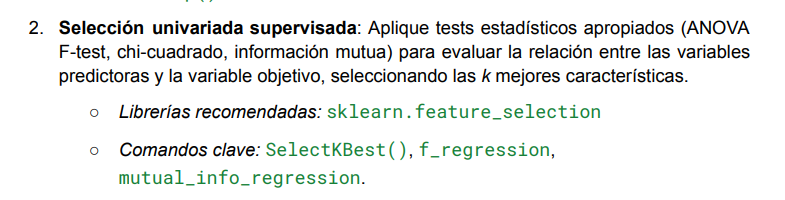

## 3.2 Filtrado univariado (F-test / información mutua)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from IPython.display import display

K_MEJORES = 15

# Reusamos TARGET/y_train/y_test ya definidos (1.1 y 1.4) - no hace falta
# reasignarlos, y evitamos colisionar con el X_train/X_test sin escalar
# de 1.4 usando nombres propios de este filtro.
X_train_post_filtro = df_train[columnas_finales]
X_test_post_filtro = df_test[columnas_finales]

print(f"Dimensión de X_train_post_filtro: {X_train_post_filtro.shape} | "
      f"X_test_post_filtro: {X_test_post_filtro.shape}")

selector_f = SelectKBest(score_func=f_regression, k=K_MEJORES)

# FIT ESTRICTAMENTE EN TRAIN
X_train_f = selector_f.fit_transform(X_train_post_filtro, y_train)
X_test_f = selector_f.transform(X_test_post_filtro) # Transformación segura del test

# Tabla de resultados
tabla_f = pd.DataFrame({
    'Característica': X_train_post_filtro.columns,
    'F_Score': selector_f.scores_,
    'p_valor': selector_f.pvalues_
}).sort_values('F_Score', ascending=False).head(K_MEJORES)

print(f"\n--- Top {K_MEJORES} Variables por F-test (ANOVA) ---")
display(
    tabla_f.style
    .format({'F_Score': "{:.2f}", 'p_valor': "{:.4e}"})
    .background_gradient(subset=['F_Score'], cmap='Blues')
    .hide(axis='index')
)


selector_mi = SelectKBest(score_func=mutual_info_regression, k=K_MEJORES)


X_train_mi = selector_mi.fit_transform(X_train_post_filtro, y_train)
X_test_mi = selector_mi.transform(X_test_post_filtro) # Transformación segura del test

# Tabla de resultados
tabla_mi = pd.DataFrame({
    'Característica': X_train_post_filtro.columns,
    'Mutual_Info': selector_mi.scores_
}).sort_values('Mutual_Info', ascending=False).head(K_MEJORES)

print(f"\n--- Top {K_MEJORES} Variables por Información Mutua ---")
display(
    tabla_mi.style
    .format({'Mutual_Info': "{:.4f}"})
    .background_gradient(subset=['Mutual_Info'], cmap='Purples')
    .hide(axis='index')
)

top_f_set = set(tabla_f['Característica'])
top_mi_set = set(tabla_mi['Característica'])
coincidencias = top_f_set.intersection(top_mi_set)

print("\n--- RESUMEN DE COINCIDENCIAS ROBUSTAS ---")
print(f"Variables seleccionadas simultáneamente por ambos métodos ({len(coincidencias)}):")
for var in sorted(coincidencias):
    print(f" ✔ {var}")

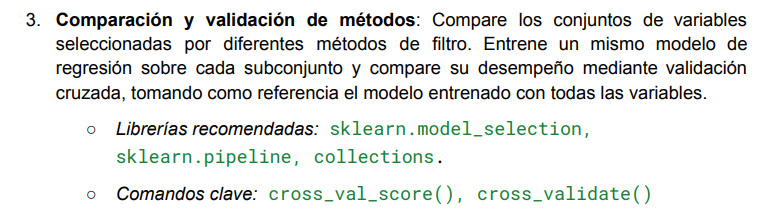

## 3.3 Comparación de subconjuntos vía validación cruzada

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate


# Reusamos el y_train global (1.4) - no hace falta reasignarlo.
X_train_completo = df_train[numeric_features]

def comparar_todos_los_subconjuntos(X_train_full, y_train, columnas_post_filtro, tabla_f, tabla_mi):
    """
    Entrena y compara mediante CV un modelo Ridge sobre 5 escenarios de reducción
    dimensional, partiendo desde el dataset original de 56 variables.
    """
    # Definición de las listas de características para cada escenario
    features_60 = list(X_train_full.columns)
    features_f = tabla_f['Característica'].tolist()
    features_mi = tabla_mi['Característica'].tolist()
    features_ambos = list(set(features_f).intersection(set(features_mi)))

    diccionario_subconjuntos = {
        '1. Dataset Original (56 variables)': features_60,
        '2. Post Filtros 3.1 (Variables descorrelacionadas)': columnas_post_filtro,
        '3. Top F-test (Relaciones Lineales)': features_f,
        '4. Top Info Mutua (Relaciones No Lineales)': features_mi,
        '5. Coincidencias Robustas (F-test + Info Mutua)': features_ambos
    }


    modelo_base = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0, random_state=42))
    ])

    resultados = []
    print("Iniciando validación cruzada (CV=5) para los 5 escenarios...\n")

    for nombre, variables in diccionario_subconjuntos.items():
        if not variables:
            continue

        # Filtramos la matriz completa según el subconjunto de turno
        X_subset = X_train_full[variables]

        cv_scores = cross_validate(
            modelo_base,
            X_subset,
            y_train,
            cv=5,
            scoring=['r2', 'neg_mean_squared_error']
        )

        resultados.append({
            'Escenario Evaluado': nombre,
            'Cant. Variables': len(variables),
            'R² Promedio (CV)': cv_scores['test_r2'].mean(),
            'Estabilidad R² (Std)': cv_scores['test_r2'].std(),
            'RMSE Promedio (CV)': np.sqrt(-cv_scores['test_neg_mean_squared_error'].mean())
        })

    return pd.DataFrame(resultados).sort_values('R² Promedio (CV)', ascending=False)


df_cv_completo = comparar_todos_los_subconjuntos(
    X_train_completo,
    y_train,
    columnas_finales,
    tabla_f,
    tabla_mi
)

print("--- TABLA COMPARATIVA DE DESEMPEÑO (Validación Cruzada Completa) ---")
display(
    df_cv_completo.style
    .format({
        'R² Promedio (CV)': "{:.4f}",
        'Estabilidad R² (Std)': "± {:.4f}",
        'RMSE Promedio (CV)': "${:,.2f}"
    })
    .background_gradient(subset=['R² Promedio (CV)'], cmap='Greens')
    .background_gradient(subset=['RMSE Promedio (CV)'], cmap='Reds_r')
    .hide(axis='index')
)
# 1. Recuperamos las 8 variables estrella (Coincidencias Robustas)
# Asumimos que 'features_ambos' es la lista de coincidencias que armaste en el paso anterior
variables_ganadoras = list(coincidencias)

# 2. Comparamos contra las 56 originales para ver cuáles quedaron en el camino
variables_descartadas = list(set(X_train_completo.columns) - set(variables_ganadoras))

print(f"🌟 VARIABLES CONSERVADAS ({len(variables_ganadoras)}):")
print("Estas son las más robustas, capturan relaciones lineales y no lineales con el PBI.")
for var in sorted(variables_ganadoras):
    print(f" ✔ {var}")

print(f"\n🗑️ VARIABLES DESCARTADAS ({len(variables_descartadas)}):")
print("Variables eliminadas para simplificar el modelo y evitar sobreajuste.")
for var in sorted(variables_descartadas):
    print(f" ❌ {var}")

A lo largo del Ejercicio 3 exploramos distintas técnicas de filtrado para descartar características y mitigar la "maldición de la dimensionalidad", partiendo esta vez de un pool de 56 variables (las 60 originales del dataset, menos las 4 excluidas por fuga de información en el Ejercicio 2.1: `gdp_current_us$`, `gdp_ppp_current_international_$`, `gdp_growth_annual` y `gdp_per_capita_growth_annual`).

El filtro de varianza casi nula no descartó ninguna variable (todas aportan variabilidad real una vez estandarizadas), y el filtro de correlación (>0.85) descartó 8 variables redundantes, dejando 48 variables tras la consigna 3.1. Sobre ese conjunto, el F-test y la información mutua (top 15 cada uno) coincidieron en 11 variables ("coincidencias robustas"), que son las que tomamos como resultado final de Ejercicio 3.

Al comparar por validación cruzada (Ridge, 5 folds) el desempeño de los 5 escenarios, obtuvimos:

| Escenario | Cant. variables | R² promedio (CV) |
|---|---|---|
| Dataset original (56 variables) | 56 | 0.9245 |
| Post filtro 3.1 (varianza + correlación) | 48 | 0.9055 |
| Top F-test (relaciones lineales) | 15 | 0.8839 |
| Coincidencias robustas (F-test + información mutua) | 11 | 0.8811 |
| Top información mutua (relaciones no lineales) | 15 | 0.8755 |

Con apenas 11 variables (un 20% de las 56 originales) se conserva un R² de 0.8811, muy cerca del 0.9245 del conjunto completo — una caída de menos de 5 puntos porcentuales a cambio de una reducción de dimensionalidad de casi el 80%. Esto confirma, ya sin las columnas de fuga que habían inflado artificialmente los resultados de una versión anterior de este análisis, que un subconjunto chico y bien elegido de variables puede sostener casi todo el poder predictivo del conjunto original.

Al analizar las 11 variables ganadoras, se agrupan en tres dimensiones socioeconómicas:

**Calidad institucional y estado de derecho**: `government_integrity`, `judicial_effectiveness`, `legal_system_and_property_rights`, `property_rights` — miden la solidez de las instituciones, la protección de la propiedad privada y la imparcialidad del sistema judicial.

**Capital humano**: `adult_literacy_rate_of_people_ages_15_and_above`, `school_enrollment_secondary_gross`, `school_enrollment_tertiary_gross` — reflejan el nivel de alfabetización y de formación educativa de la población.

**Estructura económica e infraestructura**: `access_to_electricity_of_population`, `energy_use_kg_of_oil_equivalent_per_capita`, `domestic_credit_to_private_sector_of_gdp`, `agriculture_value_added_of_gdp` — capturan el nivel de desarrollo de infraestructura energética, el dinamismo del sistema financiero y el peso del sector primario en la economía.

En síntesis, salvo por el peso del sector agrícola, casi todas estas variables están asociadas a instituciones sólidas y desarrollo humano, más que a indicadores puramente macroeconómicos de corto plazo — lo cual es consistente con la literatura de crecimiento económico de largo plazo, y refuerza que el proceso de selección de características no solo simplifica el modelo, sino que también lo vuelve más interpretable.

#Ejercicio 4

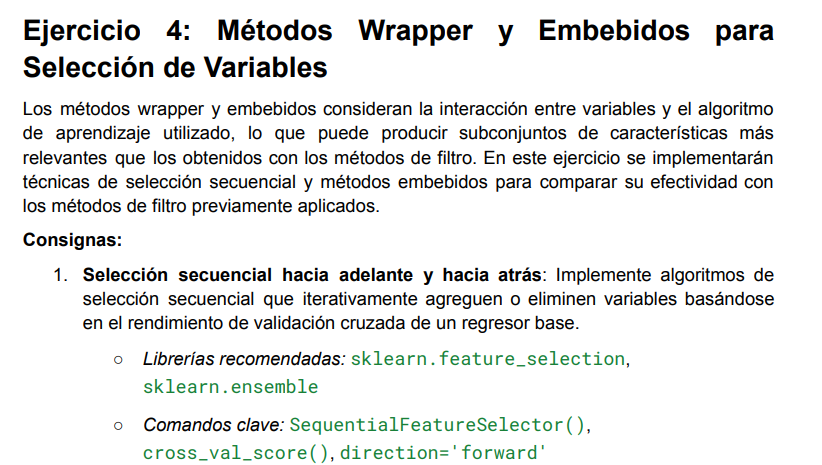

## 4.1 Selección secuencial (forward / backward)

In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score

#Regresor base
regresor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

#Validación cruzada
cv = 5


#Selección hacia adelante (Forward)
selector_forward = SequentialFeatureSelector(
    estimator=regresor,
    n_features_to_select='auto',
    direction='forward',
    scoring='r2',
    cv=cv,
    n_jobs=-1
)

selector_forward.fit(
    X_train_robust[columnas_numericas],
    y_train
)

variables_forward = X_train_robust[columnas_numericas].columns[
    selector_forward.get_support()
].tolist()

print("Variables seleccionadas - Forward:")
print(variables_forward)



KeyboardInterrupt: 

In [ ]:
#Selección hacia atrás (Backward)

selector_backward = SequentialFeatureSelector(
    estimator=regresor,
    n_features_to_select='auto',
    direction='backward',
    scoring='r2',
    cv=cv,
    n_jobs=-1
)

selector_backward.fit(
    X_train_robust[columnas_numericas],
    y_train
)

variables_backward = X_train_robust[columnas_numericas].columns[
    selector_backward.get_support()
].tolist()

print("\nVariables seleccionadas - Backward:")
print(variables_backward)

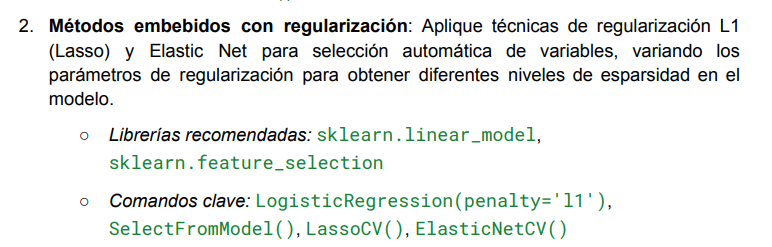

## 4.2 Regularización L1 / Elastic-Net

### Regularización L1

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel

# Selección de variables mediante regularización L1 (Lasso)

#LassoCV busca el nivel de regularización óptimo mediante validación cruzada
lasso_cv = LassoCV(
    cv=5,
    random_state=42,
    n_jobs=-1
)

#Ajustamos exclusivamente con el conjunto de entrenamiento
lasso_cv.fit(
    X_train_robust[columnas_numericas],
    y_train
)

#Seleccionamos las variables a partir de los coeficientes de Lasso

selector_lasso = SelectFromModel(
    lasso_cv,
    prefit=True
)

variables_lasso = X_train_robust[columnas_numericas].columns[
    selector_lasso.get_support()
].tolist()

# Resultados

print("Alpha seleccionado por LassoCV:", lasso_cv.alpha_)

print("\nVariables seleccionadas mediante L1 (Lasso):")
print(variables_lasso)

print(
    f"\nCantidad de variables seleccionadas: "
    f"{len(variables_lasso)} de {len(columnas_numericas)}"
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# Camino de regularización de Lasso

#Valores de alpha, desde poca hasta mucha regularización
alphas = np.logspace(-3, 2, 100)

coeficientes = []

for alpha in alphas:

    lasso = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    lasso.fit(
        X_train_robust[columnas_numericas],
        y_train
    )

    coeficientes.append(lasso.coef_)

coeficientes = np.array(coeficientes)

# Gráfico

plt.figure(figsize=(12, 7))

for i, variable in enumerate(columnas_numericas):
    plt.plot(
        alphas,
        coeficientes[:, i],
        label=variable
    )

plt.xscale('log')
plt.axhline(0, linewidth=1)

plt.xlabel('Alpha (α)')
plt.ylabel('Coeficiente')
plt.title('Camino de regularización de Lasso')
plt.grid(True, alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Regularización Elastic-Net

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.feature_selection import SelectFromModel

#Selección de variables mediante regularización Elastic Net

elastic_net_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    cv=5,
    random_state=42,
    n_jobs=-1
)

#Ajustamos exclusivamente con el conjunto de entrenamiento
elastic_net_cv.fit(
    X_train_robust[columnas_numericas],
    y_train
)

#Selección de variables a partir de los coeficientes de Elastic Net

selector_elastic_net = SelectFromModel(
    elastic_net_cv,
    prefit=True
)

variables_elastic_net = X_train_robust[columnas_numericas].columns[
    selector_elastic_net.get_support()
].tolist()

#Resultados

print("Alpha seleccionado por Elastic Net:", elastic_net_cv.alpha_)
print("L1 ratio seleccionado:", elastic_net_cv.l1_ratio_)

print("\nVariables seleccionadas mediante Elastic Net:")
print(variables_elastic_net)

print(
    f"\nCantidad de variables seleccionadas: "
    f"{len(variables_elastic_net)} de {len(columnas_numericas)}"
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet

#Camino de regularización de Elastic Net

alphas = np.logspace(-3, 2, 100)

coeficientes = []

for alpha in alphas:

    elastic_net = ElasticNet(
        alpha=alpha,
        l1_ratio=elastic_net_cv.l1_ratio_,
        max_iter=10000
    )

    elastic_net.fit(
        X_train_robust[columnas_numericas],
        y_train
    )

    coeficientes.append(elastic_net.coef_)

coeficientes = np.array(coeficientes)

#Gráfico

plt.figure(figsize=(12, 7))

for i, variable in enumerate(columnas_numericas):
    plt.plot(
        alphas,
        coeficientes[:, i],
        label=variable
    )

plt.xscale('log')
plt.axhline(0, linewidth=1)

plt.xlabel('Alpha (α)')
plt.ylabel('Coeficiente')
plt.title(
    f'Camino de regularización de Elastic Net '
    f'(l1_ratio = {elastic_net_cv.l1_ratio_:.2f})'
)

plt.grid(True, alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

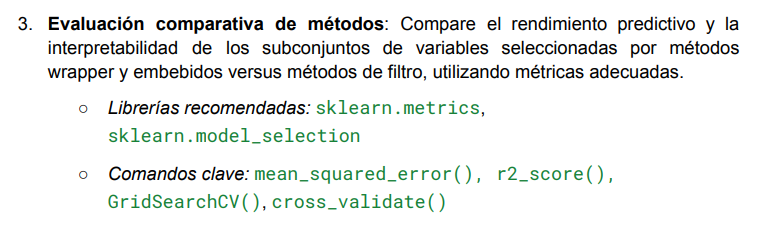

## 4.3 Comparación de métodos

In [ ]:
#Seleccionamos todas las variables obtenidas con cada metodo
subconjuntos_variables = {
    'Filtro univariado (Ejercicio 3)': variables_ganadoras,
    'Forward': variables_forward,
    'Backward': variables_backward,
    'Lasso': variables_lasso,
    'Elastic Net': variables_elastic_net
}


In [ ]:
from sklearn.model_selection import GridSearchCV
# Búsqueda de hiperparámetros del Random Forest

regresor = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

parametros_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 5]
}

grid_rf = GridSearchCV(
    estimator=regresor,
    param_grid=parametros_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [ ]:
from sklearn.model_selection import cross_validate
resultados_comparacion = []

for nombre_metodo, variables in subconjuntos_variables.items():

    grid_rf.fit(
        X_train_robust[variables],
        y_train
    )

    mejor_modelo = grid_rf.best_estimator_

    resultados_cv = cross_validate(
        mejor_modelo,
        X_train_robust[variables],
        y_train,
        cv=5,
        scoring={
            'r2': 'r2',
            'mse': 'neg_mean_squared_error'
        },
        n_jobs=-1
    )

    resultados_comparacion.append({
        'metodo': nombre_metodo,
        'variables': len(variables),
        'R2 medio': resultados_cv['test_r2'].mean(),
        'R2 std': resultados_cv['test_r2'].std(),
        'MSE medio': -resultados_cv['test_mse'].mean(),
        'MSE std': resultados_cv['test_mse'].std()
    })

In [ ]:
tabla_comparacion = pd.DataFrame(resultados_comparacion)

tabla_comparacion

In [ ]:
#Evaluamos el rendimiento predictivo en test
from sklearn.metrics import mean_squared_error, r2_score

resultados_test = []

for nombre_metodo, variables in subconjuntos_variables.items():

    grid_rf.fit(
        X_train_robust[variables],
        y_train
    )

    mejor_modelo = grid_rf.best_estimator_

    mejor_modelo.fit(
        X_train_robust[variables],
        y_train
    )

    y_pred = mejor_modelo.predict(
        X_test_robust[variables]
    )

    resultados_test.append({
        'metodo': nombre_metodo,
        'variables': len(variables),
        'R2 test': r2_score(y_test, y_pred),
        'MSE test': mean_squared_error(y_test, y_pred)
    })

tabla_test = pd.DataFrame(resultados_test)

tabla_test

# Ejercicio 5

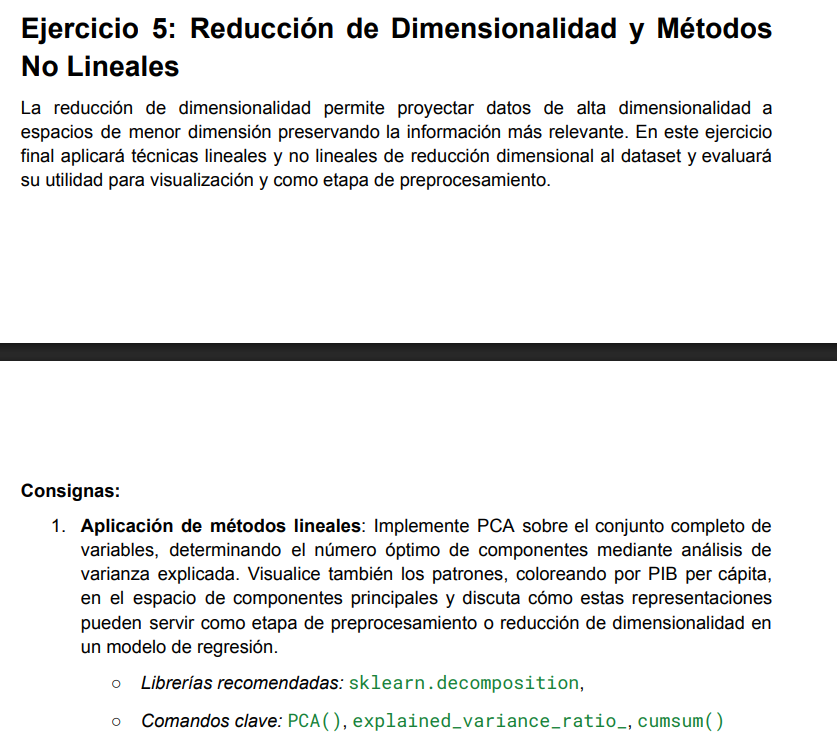

##5.1

Componentes necesarios para retener el 95% de varianza: 24


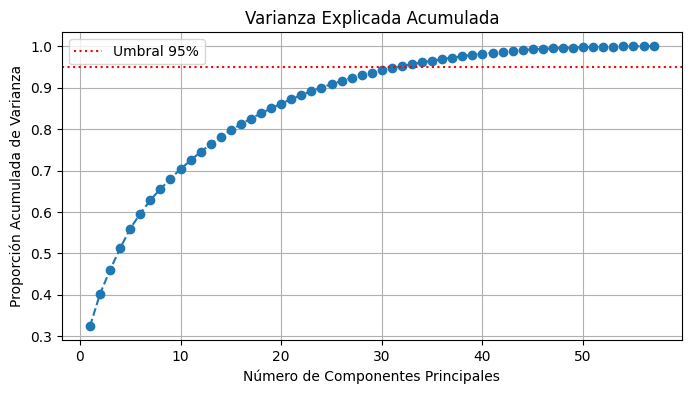

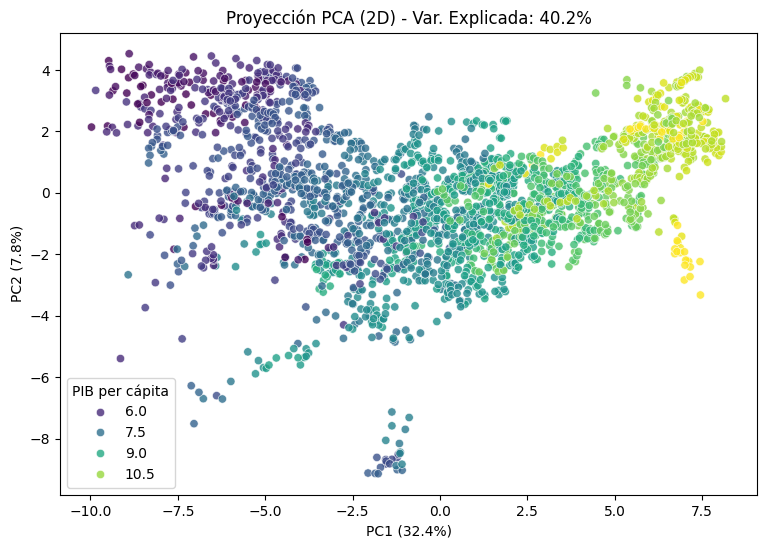

In [80]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

TARGET = 'gdp_per_capita_current_us$'
cols_a_excluir = [TARGET, 'year', 'country', 'country_name', 'country_code', 'id', 'gdp_current_us$','gdp_ppp_current_international_$']

# Filtramos las variables numéricas reales de entrada
numeric_features = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in cols_a_excluir
]



X = df_train[numeric_features].copy()
y = df_train[TARGET].copy()

# Imputación de nulos para permitir el cálculo de PCA
imputador = SimpleImputer(strategy='median')
X_imputado = pd.DataFrame(imputador.fit_transform(X), columns=X.columns)

#estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputado)

# PCA completo para calcular la varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Determinación del número óptimo para el umbral del 95%
n_optimo = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes necesarios para retener el 90% de varianza: {n_optimo}")

# Gráfico de varianza explicada acumulada
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle=':', label='Umbral 95%')
plt.title('Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción Acumulada de Varianza')
plt.grid(True)
plt.legend()
plt.show()

# Proyección a 2D y visualización coloreada por PIB per cápita
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca['PIB_per_capita'] = y.values

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2',
    hue='PIB_per_capita', palette='viridis', alpha=0.8
)
plt.title(f'Proyección PCA (2D) - Var. Explicada: {pca_2d.explained_variance_ratio_.sum():.1%}')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.legend(title='PIB per cápita')
plt.show()

El análisis de varianza explicada permite determinar cuántos componentes principales son necesarios para representar la mayor parte de la variabilidad de las variables originales. Al seleccionar los primeros componentes que acumulan al menos el 95% de la varianza, se puede reducir la dimensionalidad del conjunto de datos manteniendo la mayor parte de la información.

La representación en el espacio de los dos primeros componentes permite observar posibles patrones y agrupamientos de las observaciones según su PIB per cápita. Si se observa una separación o gradiente en los colores, esto puede indicar que parte de la variabilidad capturada por los componentes principales está asociada con el PIB per cápita.

Como etapa de preprocesamiento para un modelo de regresión, los componentes principales pueden utilizarse como nuevas variables predictoras en lugar de las variables originales. Esto reduce la dimensionalidad y puede disminuir problemas de multicolinealidad, ya que los componentes principales son ortogonales entre sí. Sin embargo, al reducir la dimensionalidad también puede descartarse información relevante para predecir específicamente el PIB per cápita, dado que PCA maximiza la varianza de las variables predictoras y no su capacidad predictiva sobre la variable objetivo.


In [ ]:
import pandas as pd
import numpy as np

# 1. Creamos un DataFrame con los pesos (loadings) de las variables
loadings_df = pd.DataFrame(
    pca_2d.components_.T,                   # Transponemos para tener las variables en las filas
    columns=['PC1', 'PC2'],                 # Los dos primeros componentes
    index=numeric_features                  # Nombres de las variables originales de entrada
)

# 2. Mostramos los coeficientes ordenados de mayor a menor impacto en PC1
print("--- COEFICIENTES DE COMBINACIÓN LINEAL (LOADINGS) ---")
display(loadings_df.sort_values(by='PC1', key=abs, ascending=False).round(4))

##5.2

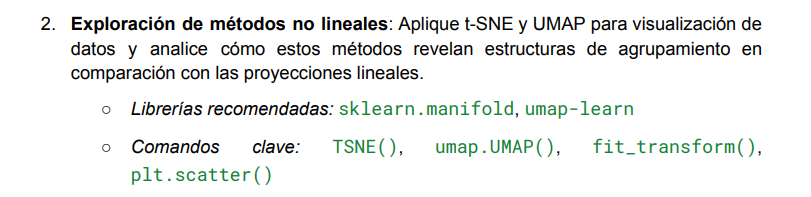

In [ ]:
X = df_robust[columnas_numericas]
y = df_robust[columna_objetivo]

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Proyección t-SNE")
plt.colorbar(label="PIB per cápita")

plt.show()

In [ ]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

reductor_umap = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = reductor_umap.fit_transform(X)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Proyección UMAP")
plt.colorbar(label="PIB per cápita")

plt.show()

## 5.3 Autocodificadores para reducción dimensional

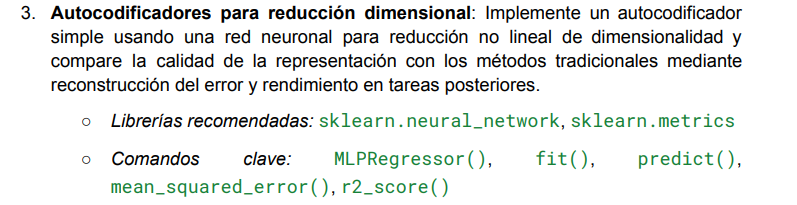

In [35]:
#Autocodificador (MLPRegressor entrenado para reconstruir su propio input) para
#reduccion NO lineal de dimensionalidad, comparado contra PCA (metodo tradicional/
#lineal) en error de reconstruccion y en el rendimiento de una tarea posterior
#(regresion del target con Ridge).

from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

# `numeric_features` YA NO SE REUSA ACA: 5.1 (que corre antes que este
# inciso) redefine esa misma variable global con su propio criterio, que no
# excluye 2 de las 4 columnas de fuga (gdp_growth_annual y
# gdp_per_capita_growth_annual quedarian adentro). En vez de heredar ese
# nombre corrupto, se recalcula localmente con el MISMO mecanismo que usa 5.1
# (columnas numericas de "df", el dataset crudo sin dividir - nunca se
# modifica, asi que no arrastra las features de ingenieria de Ejercicio 2),
# pero filtrando por la lista de fuga COMPLETA ya establecida en el resto de
# la guia (variables_excluidas_por_fuga) - da exactamente las mismas 56
# columnas que ya se usaron en Ejercicio 3/4.
numeric_features_ej5 = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in variables_excluidas_por_fuga
]
X_train_ej5 = df_train[numeric_features_ej5]

escalador_ej5 = StandardScaler()
X_train_esc = escalador_ej5.fit_transform(X_train_ej5)

# -----------------------------------------------------------------------------
# k (dimension del espacio reducido): se REUSA n_optimo, ya calculado en 5.1
# (PCA sobre df_train, varianza explicada acumulada >= 90%) - no se vuelve a
# ajustar un PCA solo para elegir k. Sigue siendo necesario ajustar PCA de
# nuevo mas abajo (holdout y cada fold de CV) porque n_optimo se calculo
# sobre TODO df_train: para evaluar reconstruccion/tarea posterior fuera de
# muestra, el ajuste tiene que hacerse solo con los datos de cada
# entrenamiento parcial, nunca con los de validacion/holdout.
k = n_optimo
print(f"k reusado de 5.1 (variables explicada >= 90%, sobre df_train): k = {k}")

# -----------------------------------------------------------------------------
# Metodo tradicional (lineal): PCA a k componentes, ajustado sobre TODO train
# (misma logica que usa Ejercicio 3.2/3.3: el ajuste no supervisado/de
# representacion se hace una vez sobre todo train, y la evaluacion fuera de
# muestra de la tarea posterior queda a cargo de cross_validate mas abajo).
# -----------------------------------------------------------------------------
pca_k = PCA(n_components=k, random_state=42)
codigo_pca_train = pca_k.fit_transform(X_train_esc)

# -----------------------------------------------------------------------------
# Autocodificador: MLPRegressor entrenado con fit(X, X) - el propio input actua
# como target, forzando a la red a comprimir y reconstruir. Arquitectura
# simetrica encoder-decoder con cuello de botella de tamano k en la capa del
# medio (misma dimension que el PCA de arriba).
# -----------------------------------------------------------------------------
INDICE_CUELLO_DE_BOTELLA = 1  # posicion de "k" dentro de hidden_layer_sizes=(32, k, 32)

def crear_autoencoder(k):
    return MLPRegressor(
        hidden_layer_sizes=(32, k, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        max_iter=2000,
        early_stopping=True,
        random_state=42,
    )

autoencoder = crear_autoencoder(k)
autoencoder.fit(X_train_esc, X_train_esc)


def extraer_codigo(mlp, X, indice_capa_oculta):
    """Forward pass manual hasta la capa del medio (el 'codigo' comprimido).
    predict() del MLPRegressor devuelve la reconstruccion completa (tamano
    original), no expone la activacion intermedia - hay que recorrer coefs_/
    intercepts_ a mano, aplicando la misma no linealidad que usa el modelo."""
    funciones_activacion = {
        'relu': lambda z: np.maximum(z, 0),
        'tanh': np.tanh,
        'logistic': lambda z: 1 / (1 + np.exp(-z)),
        'identity': lambda z: z,
    }
    activar = funciones_activacion[mlp.activation]
    activacion = X
    for i in range(indice_capa_oculta + 1):
        activacion = activar(activacion @ mlp.coefs_[i] + mlp.intercepts_[i])
    return activacion


codigo_ae_train = extraer_codigo(autoencoder, X_train_esc, INDICE_CUELLO_DE_BOTELLA)

# -----------------------------------------------------------------------------
# Comparacion 1: error de reconstruccion (que tanta informacion se perdio al
# comprimir a k dimensiones y volver a expandir), medido fuera de muestra.
#
# OJO: para esto NO se puede usar df_test. En Ejercicio 1.3 el winsorizado +
# Box-Cox de las variables asimetricas se aplico solo sobre df_train (asi se
# decidio en ese inciso), asi que varias columnas de numeric_features quedan
# en escalas completamente distintas entre df_train y df_test (ej.
# energy_use_kg_of_oil_equivalent_per_capita: ~4-10 en train tras el log,
# ~60-8400 en test sin transformar). Eso no afecta a Ejercicio 3/4 porque ahi
# todo se mide con cross_validate DENTRO de train, nunca contra df_test - pero
# reconstruccion si necesita que el holdout este en la MISMA escala que el
# train con el que se ajustan escalador/PCA/autocodificador. Por eso se arma
# un holdout propio (20%, separado por pais como el split original de 1.4)
# tomado de adentro de df_train.
# -----------------------------------------------------------------------------
divisor_holdout = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_ajuste, idx_holdout = next(divisor_holdout.split(df_train, groups=df_train['country']))

X_ajuste_recon = df_train.iloc[idx_ajuste][numeric_features_ej5]
X_holdout_recon = df_train.iloc[idx_holdout][numeric_features_ej5]

escalador_recon = StandardScaler()
X_ajuste_esc = escalador_recon.fit_transform(X_ajuste_recon)
X_holdout_esc = escalador_recon.transform(X_holdout_recon)

pca_recon = PCA(n_components=k, random_state=42).fit(X_ajuste_esc)
recon_pca_holdout = pca_recon.inverse_transform(pca_recon.transform(X_holdout_esc))

autoencoder_recon = crear_autoencoder(k)
autoencoder_recon.fit(X_ajuste_esc, X_ajuste_esc)
recon_ae_holdout = autoencoder_recon.predict(X_holdout_esc)

tabla_reconstruccion = pd.DataFrame({
    'Método': ['PCA (lineal)', 'Autocodificador (no lineal)'],
    'Dimensión reducida (k)': [k, k],
    'MSE reconstrucción (holdout, 20%)': [
        mean_squared_error(X_holdout_esc, recon_pca_holdout),
        mean_squared_error(X_holdout_esc, recon_ae_holdout),
    ],
    'R² reconstrucción (holdout, 20%)': [
        r2_score(X_holdout_esc, recon_pca_holdout),
        r2_score(X_holdout_esc, recon_ae_holdout),
    ],
})

print("\n--- ERROR DE RECONSTRUCCIÓN (holdout dentro de train): PCA vs. Autocodificador ---")
estilizar_tabla(
    tabla_reconstruccion,
    columnas_gradiente_invertido=['MSE reconstrucción (holdout, 20%)'],
    columnas_gradiente=['R² reconstrucción (holdout, 20%)'],
    titulo=f'Error de reconstrucción — PCA vs. Autocodificador (k={k})',
)

# -----------------------------------------------------------------------------
# Comparacion 2: rendimiento en una tarea posterior (Ridge sobre el target).
#
# CORRECCION DE FUGA DE DATOS: la version anterior ajustaba PCA y el
# autocodificador sobre TODO X_train antes de correr la validacion cruzada
# sobre esas representaciones ya reducidas. Eso es fuga real: la
# representacion de cada observacion de validacion ya habia sido influida por
# esa misma observacion (via la matriz de covarianza de PCA, o via los pesos
# aprendidos por la red) antes de "evaluarla" como si fuera nueva - infla el
# R² de forma optimista. La version correcta reajusta StandardScaler y
# PCA/autocodificador DENTRO de cada fold, usando unicamente el fold de
# entrenamiento (Pipeline no alcanza aca porque hay que intercalar la
# extraccion del bottleneck del autocodificador entre el escalado y el Ridge
# final, asi que se usa un loop explicito).
#
# GroupKFold (no KFold): el dataset es un panel pais-anio (multiples filas por
# pais - en train, ~2564 filas repartidas en 108 paises). Con KFold comun,
# filas del MISMO pais podrian caer una en el fold de entrenamiento y otra en
# el de validacion dentro de la misma iteracion, dejando que el modelo
# "reconozca" el nivel de ese pais en vez de generalizar - mismo motivo por el
# que el split original de 1.4 y el holdout de reconstruccion de mas arriba
# agrupan por pais.
# -----------------------------------------------------------------------------
particionador_tarea = GroupKFold(n_splits=5)
folds_tarea = list(particionador_tarea.split(X_train_ej5, y_train, groups=df_train['country']))


def representacion_original(X_tr, X_val):
    escalador_fold = StandardScaler()
    return escalador_fold.fit_transform(X_tr), escalador_fold.transform(X_val)


def representacion_pca(X_tr, X_val):
    escalador_fold = StandardScaler()
    X_tr_esc = escalador_fold.fit_transform(X_tr)
    X_val_esc = escalador_fold.transform(X_val)
    pca_fold = PCA(n_components=k, random_state=42)
    return pca_fold.fit_transform(X_tr_esc), pca_fold.transform(X_val_esc)


def representacion_autoencoder(X_tr, X_val):
    escalador_fold = StandardScaler()
    X_tr_esc = escalador_fold.fit_transform(X_tr)
    X_val_esc = escalador_fold.transform(X_val)
    ae_fold = crear_autoencoder(k)
    ae_fold.fit(X_tr_esc, X_tr_esc)
    return (
        extraer_codigo(ae_fold, X_tr_esc, INDICE_CUELLO_DE_BOTELLA),
        extraer_codigo(ae_fold, X_val_esc, INDICE_CUELLO_DE_BOTELLA),
    )


def evaluar_representacion_cv(obtener_representacion, nombre, dimension):
    """Por cada fold: ajusta la representacion (escalador, y si corresponde
    PCA/autocodificador) UNICAMENTE con el fold de entrenamiento, y evalua
    Ridge (tambien ajustado solo ahi) sobre el fold de validacion - ninguna
    transformacion ve jamas las filas con las que despues se la evalua."""
    r2s, rmses = [], []
    for idx_train, idx_val in folds_tarea:
        X_tr = X_train_ej5.iloc[idx_train]
        X_val = X_train_ej5.iloc[idx_val]
        y_tr = y_train.iloc[idx_train]
        y_val = y_train.iloc[idx_val]

        repr_tr, repr_val = obtener_representacion(X_tr, X_val)

        modelo_fold = Ridge(alpha=1.0, random_state=42)
        modelo_fold.fit(repr_tr, y_tr)
        pred_val = modelo_fold.predict(repr_val)

        r2s.append(r2_score(y_val, pred_val))
        rmses.append(np.sqrt(mean_squared_error(y_val, pred_val)))

    return {
        'Representación': nombre,
        'Dimensión': dimension,
        'R² promedio (CV)': np.mean(r2s),
        'RMSE promedio (CV)': np.mean(rmses),
    }


resultados_tarea = pd.DataFrame([
    evaluar_representacion_cv(representacion_original, f'Dataset original ({X_train_ej5.shape[1]} variables, sin reducir)', X_train_ej5.shape[1]),
    evaluar_representacion_cv(representacion_pca, f'PCA (k={k} componentes)', k),
    evaluar_representacion_cv(representacion_autoencoder, f'Autocodificador (k={k}, no lineal)', k),
]).sort_values('R² promedio (CV)', ascending=False)

print("\n--- RENDIMIENTO EN TAREA POSTERIOR (Ridge, CV=5 agrupada por país) ---")
estilizar_tabla(
    resultados_tarea,
    columnas_gradiente=['R² promedio (CV)'],
    columnas_gradiente_invertido=['RMSE promedio (CV)'],
    titulo=f'Rendimiento en tarea posterior — original vs. reducciones a k={k}',
)


k reusado de 5.1 (variables explicada >= 90%, sobre df_train): k = 24



--- ERROR DE RECONSTRUCCIÓN (holdout dentro de train): PCA vs. Autocodificador ---


Método,Dimensión reducida (k),"MSE reconstrucción (holdout, 20%)","R² reconstrucción (holdout, 20%)"
PCA (lineal),24,0.166,0.710
Autocodificador (no lineal),24,0.159,0.733



--- RENDIMIENTO EN TAREA POSTERIOR (Ridge, CV=5 agrupada por país) ---


Representación,Dimensión,R² promedio (CV),RMSE promedio (CV)
"Dataset original (56 variables, sin reducir)",56,0.910,0.460
"Autocodificador (k=24, no lineal)",24,0.887,0.503
PCA (k=24 componentes),24,0.866,0.548


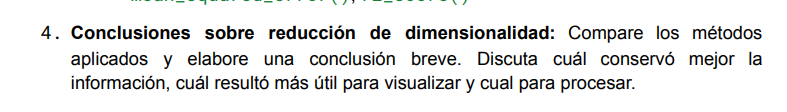

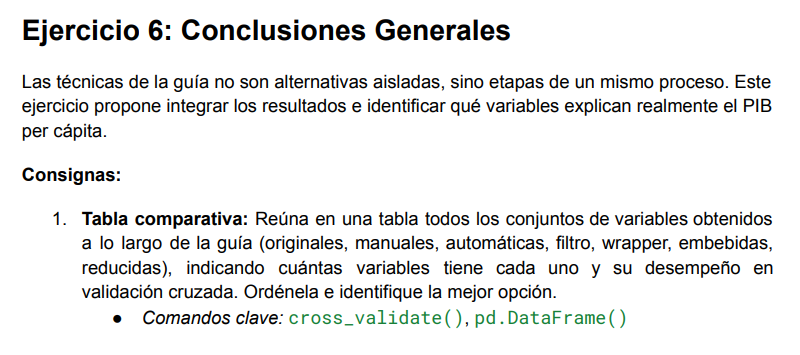

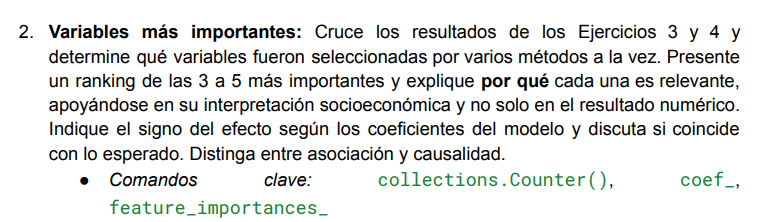

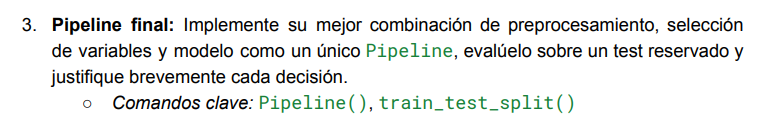

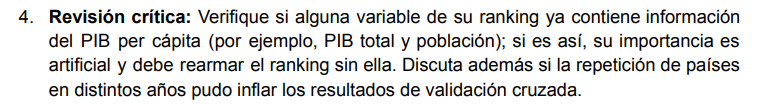

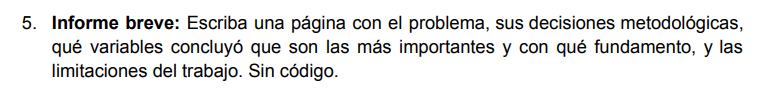

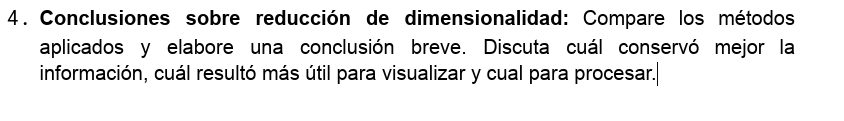